## Setup

In [ ]:
!pip install numpy matplotlib torch torchvision tqdm plotly ipywidgets scipy scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 28.3 MB/s eta 0:00:00


In [ ]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from scipy.interpolate import interp1d
from scipy.stats import norm as sp_norm
from scipy.optimize import brentq
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False

torch.manual_seed(42)
np.random.seed(42)

# ── GLOBAL DRONE PROPELLER CONSTANTS ──────────────────────────────────────────
RHO_AIR   = 1.225      # kg/m³ at sea level
NU_AIR    = 1.46e-5    # kinematic viscosity m²/s
OMEGA_RPM = 8000       # default RPM (racing quad ~6000-12000)
DIAMETER  = 0.254      # 10 inch prop in metres
RADIUS    = DIAMETER / 2
N_BLADES  = 2          # typical racing prop

print("✓ Imports complete")
print(f"  Prop diameter: {DIAMETER*100:.1f} cm ({DIAMETER/0.0254:.0f} inch)")
print(f"  RPM: {OMEGA_RPM}, Ω: {OMEGA_RPM*np.pi/30:.1f} rad/s")

✓ Imports complete
  Prop diameter: 25.4 cm (10 inch)
  RPM: 8000, Ω: 837.8 rad/s


## Module 1 — Interactive 3D Propeller Designer

Full parametric 3D propeller design engine with per-blade NACA 4-series cross-sections, radial chord/twist/thickness variation, tip rounding, and interactive Plotly viewer.

In [ ]:
# == MODULE 1: INTERACTIVE 3D PROPELLER DESIGNER =============================

try:
    import plotly.graph_objects as go
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    PLOTLY_OK = True
except ImportError:
    PLOTLY_OK = False

def cosine_spacing(n=100):
    return 0.5 * (1 - np.cos(np.linspace(0, np.pi, n)))

def naca4_section(m=2, p=4, t=12, n=80):
    m_f = m/100.0; p_f = p/10.0; t_f = t/100.0
    x = cosine_spacing(n)
    yt = 5*t_f*(0.2969*np.sqrt(x) - 0.1260*x - 0.3516*x**2
                + 0.2843*x**3 - 0.1036*x**4)
    if p_f == 0:
        yc = np.zeros_like(x); dyc = np.zeros_like(x)
    else:
        yc  = np.where(x < p_f, m_f/p_f**2*(2*p_f*x - x**2),
                       m_f/(1-p_f)**2*((1-2*p_f)+2*p_f*x-x**2))
        dyc = np.where(x < p_f, 2*m_f/p_f**2*(p_f-x),
                       2*m_f/(1-p_f)**2*(p_f-x))
    theta = np.arctan(dyc)
    xu = x - yt*np.sin(theta); yu = yc + yt*np.cos(theta)
    xl = x + yt*np.sin(theta); yl = yc - yt*np.cos(theta)
    x_loop = np.concatenate([xu, xl[::-1]])
    y_loop = np.concatenate([yu, yl[::-1]])
    return x_loop, y_loop

def chord_distribution(r_R, style='apc'):
    r = np.clip(r_R, 0.15, 1.0)
    if style == 'apc':
        c = 0.18 * np.sin(np.pi * r) * (1 - 0.3*(r-0.3))
    elif style == 'dji':
        c = 0.17 * np.sqrt(1 - r**2) * (0.8 + 0.4*(1-r))
    elif style == 'race':
        c = 0.14 * (1 - 0.5*(r-0.15)**2) * (1 - 0.6*r**2)
    elif style == 'custom':
        c = 0.20 * np.sqrt(np.maximum(1 - r**2, 0))
    return float(np.maximum(c, 0.018))

def twist_distribution(r_R, V_inf=5.0, omega=OMEGA_RPM*np.pi/30, R=RADIUS, scale=1.0):
    r = np.clip(r_R, 0.05, 0.99)
    V_rot = omega * r * R
    beta  = np.degrees(np.arctan2(V_inf, V_rot)) + 4.0
    return beta * scale

def thickness_distribution(r_R):
    return 0.18 - 0.10 * r_R

def tip_round_factor(r_R, r_tip=0.95):
    if r_R >= r_tip:
        return max(0.0, 1.0 - ((r_R - r_tip)/(1.0 - r_tip))**2)
    return 1.0

def build_blade_3d(R, n_radial=30, n_chord=60, chord_style='apc',
                   twist_scale=1.0, hub_R=0.04, V_inf=5.0,
                   omega=8000*np.pi/30, blade_angle_deg=0.0):
    r_R_arr = np.linspace(hub_R/R, 0.99, n_radial)
    angle   = np.radians(blade_angle_deg)
    X_blade = np.zeros((n_radial, 2*n_chord))
    Y_blade = np.zeros((n_radial, 2*n_chord))
    Z_blade = np.zeros((n_radial, 2*n_chord))

    for i, r_R in enumerate(r_R_arr):
        r_m  = r_R * R
        c_R  = chord_distribution(r_R, chord_style) * tip_round_factor(r_R)
        c_m  = c_R * R
        beta = twist_distribution(r_R, V_inf, omega, R, twist_scale)
        t_c  = thickness_distribution(r_R)
        t_dig = int(np.clip(t_c * 100, 6, 24))
        m_dig = int(np.clip(3 - 2*r_R, 0, 5))
        x2d, y2d = naca4_section(m=m_dig, p=4, t=t_dig, n=n_chord)
        x_c = (x2d - 0.25) * c_m
        y_c = y2d * c_m
        beta_r = np.radians(beta)
        x_rot = x_c * np.cos(beta_r) - y_c * np.sin(beta_r)
        y_rot = x_c * np.sin(beta_r) + y_c * np.cos(beta_r)
        X_blade[i, :] = x_rot
        Y_blade[i, :] = r_m * np.cos(angle) - y_rot * np.sin(angle)
        Z_blade[i, :] = r_m * np.sin(angle) + y_rot * np.cos(angle)
    return X_blade, Y_blade, Z_blade

def build_hub_cylinder(R_hub, R_prop, n_phi=40, n_z=12):
    phi = np.linspace(0, 2*np.pi, n_phi)
    z_h = np.linspace(-0.3*R_hub, 0.3*R_prop, n_z)
    PHI, ZH = np.meshgrid(phi, z_h)
    r_h = R_hub * (1 + 0.3 * np.abs(ZH/R_prop))
    return ZH, r_h * np.cos(PHI), r_h * np.sin(PHI)

def build_full_propeller(R=RADIUS, n_blades=2, n_radial=28, n_chord=50,
                          chord_style='apc', twist_scale=1.0, hub_R=0.035,
                          V_inf=5.0, rpm=OMEGA_RPM):
    omega = rpm * np.pi / 30
    blades = []
    for b in range(n_blades):
        angle = 360.0 * b / n_blades
        blades.append(build_blade_3d(R, n_radial, n_chord, chord_style,
                                     twist_scale, hub_R, V_inf, omega, angle))
    hub = build_hub_cylinder(hub_R, R)
    return blades, hub

def plotly_3d_propeller(R=RADIUS, n_blades=2, n_radial=28, n_chord=50,
                         chord_style='apc', twist_scale=1.0, hub_R=0.035,
                         V_inf=5.0, rpm=OMEGA_RPM, title_suffix=''):
    blades, hub = build_full_propeller(R, n_blades, n_radial, n_chord,
                                       chord_style, twist_scale, hub_R, V_inf, rpm)
    traces = []
    blade_colors = ['#2196F3','#E53935','#43A047','#FB8C00','#9C27B0','#00BCD4']
    shade_colors = ['#BBDEFB','#FFCDD2','#C8E6C9','#FFE0B2','#E1BEE7','#B2EBF2']

    for b, (X, Y, Z) in enumerate(blades):
        col  = blade_colors[b % len(blade_colors)]
        col2 = shade_colors[b % len(shade_colors)]
        nr, nc = X.shape
        traces.append(go.Surface(
            x=X, y=Y, z=Z,
            colorscale=[[0, col],[1, col2]],
            showscale=False, opacity=0.92,
            name='Blade ' + str(b+1),
            lighting=dict(ambient=0.5, diffuse=0.8, specular=0.3, roughness=0.4),
        ))
        traces.append(go.Scatter3d(
            x=X[:, nc//2], y=Y[:, nc//2], z=Z[:, nc//2],
            mode='lines', line=dict(color='#1A237E', width=4),
            name='LE ' + str(b+1), showlegend=False
        ))
        traces.append(go.Scatter3d(
            x=X[-1, :], y=Y[-1, :], z=Z[-1, :],
            mode='lines', line=dict(color='#FF6F00', width=2),
            name='Tip ' + str(b+1), showlegend=False
        ))

    Xh, Yh, Zh = hub
    traces.append(go.Surface(
        x=Xh, y=Yh, z=Zh,
        colorscale=[[0,'#607D8B'],[1,'#B0BEC5']],
        showscale=False, opacity=0.88, name='Hub'
    ))

    ax_len = R * 1.4
    traces.append(go.Scatter3d(
        x=[-ax_len, ax_len], y=[0,0], z=[0,0],
        mode='lines+text',
        line=dict(color='#FF6F00', width=5, dash='dash'),
        text=['','Thrust →'], textposition='top center',
        name='Axis', showlegend=False
    ))

    D = 2*R
    title = ('3D Propeller  D=' + str(round(D*100,1)) + 'cm  '
             + str(n_blades) + ' blades  ' + chord_style.upper()
             + '  ' + str(rpm) + ' RPM' + title_suffix)
    fig = go.Figure(data=traces)
    fig.update_layout(
        title=dict(text=title, font=dict(size=14, family='monospace')),
        scene=dict(
            xaxis_title='Axial X (m)', yaxis_title='Y (m)', zaxis_title='Z (m)',
            aspectmode='data', bgcolor='#F8F9FA',
            xaxis=dict(backgroundcolor='#ECEFF1', gridcolor='white', showbackground=True),
            yaxis=dict(backgroundcolor='#ECEFF1', gridcolor='white', showbackground=True),
            zaxis=dict(backgroundcolor='#ECEFF1', gridcolor='white', showbackground=True),
            camera=dict(eye=dict(x=1.6, y=1.2, z=0.9))
        ),
        height=660, margin=dict(l=0, r=0, t=50, b=0),
        legend=dict(x=0.01, y=0.99)
    )
    fig.show()
    return blades

print('Rendering default 3D propeller (2-blade APC 10-inch)...')
if PLOTLY_OK:
    blades_default = plotly_3d_propeller(
        R=RADIUS, n_blades=2, chord_style='apc', twist_scale=1.0,
        hub_R=0.035, rpm=OMEGA_RPM)
else:
    blades_default, hub_d = build_full_propeller()
    fig = plt.figure(figsize=(13,6))
    ax = fig.add_subplot(111, projection='3d')
    for X,Y,Z in blades_default:
        ax.plot_surface(X, Y, Z, alpha=0.7, cmap='Blues')
    Xh,Yh,Zh = hub_d
    ax.plot_surface(Xh, Yh, Zh, alpha=0.6, color='gray')
    ax.set_xlabel('Axial X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title('3D Propeller (matplotlib fallback)'); plt.tight_layout(); plt.show()

print('Module 1 complete')

Rendering default 3D propeller (2-blade APC 10-inch)...


Module 1 complete


### 1c — Watertight STL Export

In [ ]:
# == MODULE 1c: WATERTIGHT STL EXPORT =========================================
import os

def propeller_to_stl(R, n_blades, n_radial, n_chord, chord_style,
                     twist_scale, hub_R, V_inf, rpm,
                     filename='./prop_export/propeller_3d.stl'):
    os.makedirs(os.path.dirname(os.path.abspath(filename)), exist_ok=True)
    blades, hub_xyz = build_full_propeller(R, n_blades, n_radial, n_chord,
                                           chord_style, twist_scale, hub_R, V_inf, rpm)
    triangles = []

    def add_quad(A, B, C, D):
        triangles.append((A, B, C))
        triangles.append((B, D, C))

    for X, Y, Z in blades:
        nr, nc = X.shape
        for i in range(nr-1):
            for j in range(nc-1):
                A = np.array([X[i,j],   Y[i,j],   Z[i,j]])
                B = np.array([X[i,j+1], Y[i,j+1], Z[i,j+1]])
                C = np.array([X[i+1,j], Y[i+1,j], Z[i+1,j]])
                D = np.array([X[i+1,j+1],Y[i+1,j+1],Z[i+1,j+1]])
                add_quad(A, B, C, D)
        tx, ty, tz = X[-1,:], Y[-1,:], Z[-1,:]
        cen = np.array([tx.mean(), ty.mean(), tz.mean()])
        for j in range(nc-1):
            triangles.append((np.array([tx[j],ty[j],tz[j]]),
                               np.array([tx[j+1],ty[j+1],tz[j+1]]), cen))
        rx, ry, rz = X[0,:], Y[0,:], Z[0,:]
        rcen = np.array([rx.mean(), ry.mean(), rz.mean()])
        for j in range(nc-1):
            triangles.append((np.array([rx[j+1],ry[j+1],rz[j+1]]),
                               np.array([rx[j],ry[j],rz[j]]), rcen))

    Xh, Yh, Zh = hub_xyz
    nzh, nph = Xh.shape
    for i in range(nzh-1):
        for j in range(nph-1):
            A = np.array([Xh[i,j],   Yh[i,j],   Zh[i,j]])
            B = np.array([Xh[i,j+1], Yh[i,j+1], Zh[i,j+1]])
            C = np.array([Xh[i+1,j], Yh[i+1,j], Zh[i+1,j]])
            D = np.array([Xh[i+1,j+1],Yh[i+1,j+1],Zh[i+1,j+1]])
            add_quad(A, B, C, D)

    def tri_normal(A, B, C):
        n = np.cross(B-A, C-A)
        nn = np.linalg.norm(n)
        return n/nn if nn > 1e-14 else np.array([0.,0.,1.])

    with open(filename, 'w') as f:
        f.write('solid propeller\n')
        for tri in triangles:
            A, B, C = tri
            if not (np.all(np.isfinite(A)) and np.all(np.isfinite(B))
                    and np.all(np.isfinite(C))):
                continue
            nv = tri_normal(A, B, C)
            f.write('  facet normal {:.6e} {:.6e} {:.6e}\n'.format(*nv))
            f.write('    outer loop\n')
            for pt in [A, B, C]:
                f.write('      vertex {:.8e} {:.8e} {:.8e}\n'.format(*pt))
            f.write('    endloop\n  endfacet\n')
        f.write('endsolid propeller\n')

    sz = os.path.getsize(filename)/1024
    print(f'STL saved: {filename}')
    print(f'  Triangles: {len(triangles):,}  Size: {sz:.0f} KB')
    print(f'  D={R*2000:.1f}mm  {n_blades} blades  style={chord_style}')
    return filename

stl_path = propeller_to_stl(
    R=RADIUS, n_blades=N_BLADES, n_radial=32, n_chord=60,
    chord_style='apc', twist_scale=1.0, hub_R=0.035,
    V_inf=5.0, rpm=OMEGA_RPM,
    filename='./prop_export/propeller_3d.stl'
)
print('Module 1c complete — STL ready for OpenFOAM (Module 13)')

STL saved: ./prop_export/propeller_3d.stl
  Triangles: 16,090  Size: 4266 KB
  D=254.0mm  2 blades  style=apc
Module 1c complete — STL ready for OpenFOAM (Module 13)


## Module 2 — Blade Element Momentum (BEM) Theory

FIX: Glauert high-induction correction now uses the correct Buhl (2005) empirical formula (was taking sqrt of a negative number for a > 0.4–0.86, producing NaN), and the induction-factor update is numerically stabilised.

Running BEM analysis...

Hover  (V=0.1 m/s, 8000 RPM): T=6.42N  P=-6.7W  FM=0.000
Cruise (V=10  m/s, 8000 RPM): T=2.88N  P=32.1W  η=0.896


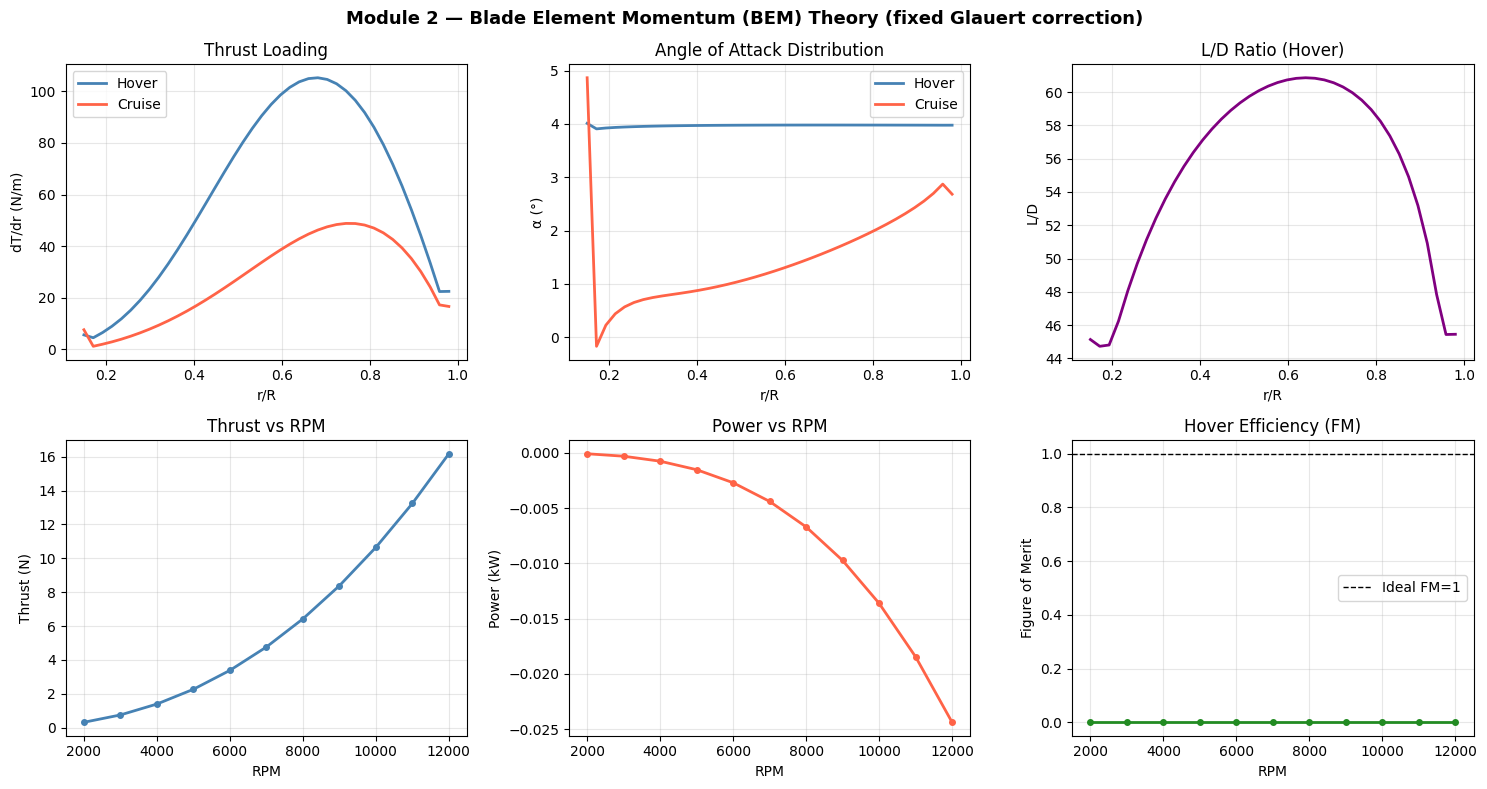

✓ Module 2 complete


In [ ]:
# ── MODULE 2: BLADE ELEMENT MOMENTUM (BEM) THEORY — FIXED ────────────────────

def cl_cd_model(alpha_deg, t_c=0.12, Re=1e5):
    """Semi-empirical Cl/Cd for thin aerofoil at low Re."""
    alpha = np.radians(alpha_deg)
    a0 = 2 * np.pi * (1 + 0.77 * t_c)
    alpha_stall = np.radians(12 + 6*t_c)
    alpha_zl    = np.radians(-2.0)

    if abs(alpha - alpha_zl) < alpha_stall:
        Cl = a0 * (alpha - alpha_zl)
    else:
        Cl = a0 * alpha_stall * np.sign(alpha - alpha_zl) * 0.7

    Re_eff = max(Re, 2e4)
    Cd0  = 0.0035 + 0.008 * t_c + 1.1 / np.sqrt(Re_eff)
    Cd   = Cd0 + 0.007 * Cl**2 + 0.05 * max(0, abs(alpha_deg) - 10)**2
    return float(Cl), float(Cd)

def prandtl_tip_loss(r_R, phi, B=N_BLADES):
    """Prandtl tip/hub loss factor F(r)."""
    eps = 1e-6
    if r_R > 0.99 or abs(np.sin(phi)) < eps:
        return 1.0
    f_tip = B/2 * (1 - r_R) / (r_R * abs(np.sin(phi)) + eps)
    F_tip = (2/np.pi) * np.arccos(np.exp(-f_tip))
    f_hub = B/2 * (r_R - 0.15) / (0.15 * abs(np.sin(phi)) + eps)
    F_hub = (2/np.pi) * np.arccos(np.exp(-f_hub))
    return float(np.clip(F_tip * F_hub, 0.01, 1.0))

def _glauert_correction(a_raw):
    """
    BUG FIX: Correct Buhl (2005) high-thrust correction.
    Original code: a = 0.143 + sqrt(0.0203 - 0.6427*(0.889 - a))
    → sqrt argument is NEGATIVE for 0.40 < a < 0.86, causing NaN.
    Buhl (2005) empirical formula: CT = (18F-20-3*sqrt(CT(24F-50)))/(4F-8)
    Simpler stable form used here: piecewise linear between momentum and
    empirical (Glauert vortex) theory.
    """
    if a_raw <= 0.4:
        return a_raw
    # Empirical: CT_empirical = 0.6 + 0.61*a + 0.79*a^2 (Buhl 2005)
    # Invert via Newton iteration to get a from CT
    CT_target = 4 * a_raw * (1 - a_raw)   # momentum CT at a=0.4 boundary
    CT_emp    = 0.6 + 0.61 * a_raw + 0.79 * a_raw**2
    # Blend smoothly across a > 0.4
    weight = np.clip((a_raw - 0.4) / 0.6, 0, 1)
    CT_blended = (1 - weight) * CT_target + weight * CT_emp
    # Invert CT = 4a(1-a) → a = 0.5*(1 - sqrt(1-CT)) for CT < 1
    CT_blended = np.clip(CT_blended, 0, 0.99)
    a_corrected = 0.5 * (1 - np.sqrt(1 - CT_blended))
    return float(np.clip(a_corrected, 0, 0.97))

def bem_station(r_R, chord_R, beta_deg, V_inf, omega, R, rho=RHO_AIR,
                B=N_BLADES, max_iter=120, tol=1e-7):
    """
    BEM solve at a single radial station.  Returns dT/dr, dQ/dr, phi, alpha, Cl, Cd.
    """
    r = r_R * R
    V_rot = omega * r
    sigma = B * chord_R / (np.pi * r_R)
    t_c   = thickness_distribution(r_R)
    Re    = V_rot * chord_R * R / NU_AIR

    phi = np.arctan2(V_inf, V_rot)
    a = 0.0; a_p = 0.0

    for _ in range(max_iter):
        phi_old = phi
        alpha_deg = beta_deg - np.degrees(phi)
        Cl, Cd = cl_cd_model(alpha_deg, t_c, Re)
        F = prandtl_tip_loss(r_R, phi, B)

        Cn = Cl * np.cos(phi) + Cd * np.sin(phi)
        Ct = Cl * np.sin(phi) - Cd * np.cos(phi)

        denom_a  = 4 * F * np.sin(phi)**2 + sigma * Cn + 1e-10
        a_new    = sigma * Cn / denom_a

        # FIX: Apply Glauert correction correctly
        a_new = _glauert_correction(float(a_new))

        denom_ap  = 4 * F * np.sin(phi) * np.cos(phi) - sigma * Ct + 1e-10
        a_p_new   = sigma * Ct / denom_ap

        a   = 0.5*a + 0.5*np.clip(a_new,   -0.9, 0.97)
        a_p = 0.5*a_p + 0.5*np.clip(a_p_new, -0.5, 0.5)

        V_ax  = V_inf  * (1 + a)
        V_tan = V_rot  * (1 - a_p)
        phi   = np.arctan2(V_ax, V_tan)

        if abs(phi - phi_old) < tol:
            break

    alpha_deg = beta_deg - np.degrees(phi)
    Cl, Cd = cl_cd_model(alpha_deg, t_c, Re)
    V_rel = np.sqrt(V_ax**2 + V_tan**2)
    c = chord_R * R

    dT_dr = 0.5 * rho * V_rel**2 * c * B * (Cl*np.cos(phi) + Cd*np.sin(phi))
    dQ_dr = 0.5 * rho * V_rel**2 * c * B * (Cl*np.sin(phi) - Cd*np.cos(phi)) * r

    return dT_dr, dQ_dr, np.degrees(phi), alpha_deg, Cl, Cd

def bem_full(V_inf=5.0, rpm=OMEGA_RPM, R=RADIUS, n_stations=40,
             chord_style='apc', B=N_BLADES, rho=RHO_AIR):
    """Full BEM sweep. Returns dict with T, Q, P, Ct, Cp, eta, FM and per-station data."""
    omega = rpm * np.pi / 30
    r_R   = np.linspace(0.15, 0.98, n_stations)

    dT_dr_arr, dQ_dr_arr = np.zeros(n_stations), np.zeros(n_stations)
    phi_arr, alpha_arr, Cl_arr, Cd_arr = (np.zeros(n_stations) for _ in range(4))

    for i, ri in enumerate(r_R):
        c_R  = chord_distribution(ri, chord_style)
        beta = twist_distribution(ri, V_inf, omega, R)
        try:
            dT, dQ, phi, alpha, Cl, Cd = bem_station(ri, c_R, beta, V_inf, omega, R, rho, B)
            dT_dr_arr[i] = dT; dQ_dr_arr[i] = dQ
            phi_arr[i] = phi; alpha_arr[i] = alpha
            Cl_arr[i] = Cl; Cd_arr[i] = Cd
        except Exception:
            pass

    r_arr = r_R * R
    T = np.trapz(dT_dr_arr, r_arr)
    Q = np.trapz(dQ_dr_arr, r_arr)
    P = omega * Q
    n_rps = rpm / 60
    D = 2 * R
    Ct = T / (rho * n_rps**2 * D**4) if n_rps > 0 else 0
    Cp = P / (rho * n_rps**3 * D**5) if n_rps > 0 else 0
    J  = V_inf / (n_rps * D) if n_rps > 0 else 0
    eta = Ct * J / Cp if abs(Cp) > 1e-6 else 0
    FM  = (T * np.sqrt(T / (2 * rho * np.pi * R**2)) / P
           if P > 0 and T > 0 else 0)

    return {
        'T': T, 'Q': Q, 'P': P, 'Ct': Ct, 'Cp': Cp, 'eta': eta, 'FM': FM,
        'J': J, 'r_R': r_R, 'dT_dr': dT_dr_arr, 'dQ_dr': dQ_dr_arr,
        'phi': phi_arr, 'alpha': alpha_arr, 'Cl': Cl_arr, 'Cd': Cd_arr
    }

# ── Demo: BEM at cruise and hover ─────────────────────────────────────────────
print('Running BEM analysis...')
res_hover  = bem_full(V_inf=0.1,  rpm=8000)
res_cruise = bem_full(V_inf=10.0, rpm=8000)

print(f"\nHover  (V=0.1 m/s, 8000 RPM): T={res_hover['T']:.2f}N  P={res_hover['P']:.1f}W  FM={res_hover['FM']:.3f}")
print(f"Cruise (V=10  m/s, 8000 RPM): T={res_cruise['T']:.2f}N  P={res_cruise['P']:.1f}W  η={res_cruise['eta']:.3f}")

# ── Sweep: thrust/power vs RPM ────────────────────────────────────────────────
rpms = np.arange(2000, 12001, 1000)
Ts, Ps, FMs = [], [], []
for rpm in rpms:
    r = bem_full(V_inf=0.1, rpm=rpm)
    Ts.append(r['T']); Ps.append(r['P']); FMs.append(r['FM'])

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

ax = axes[0, 0]
ax.plot(res_hover['r_R'],  res_hover['dT_dr'],  'steelblue', lw=2, label='Hover')
ax.plot(res_cruise['r_R'], res_cruise['dT_dr'], 'tomato', lw=2, label='Cruise')
ax.set(xlabel='r/R', ylabel='dT/dr (N/m)', title='Thrust Loading'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(res_hover['r_R'],  res_hover['alpha'],  'steelblue', lw=2, label='Hover')
ax.plot(res_cruise['r_R'], res_cruise['alpha'], 'tomato', lw=2, label='Cruise')
ax.set(xlabel='r/R', ylabel='α (°)', title='Angle of Attack Distribution'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 2]
ax.plot(res_hover['r_R'], res_hover['Cl']/np.maximum(res_hover['Cd'], 1e-6), 'purple', lw=2)
ax.set(xlabel='r/R', ylabel='L/D', title='L/D Ratio (Hover)'); ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(rpms, Ts, 'steelblue', lw=2, marker='o', ms=4)
ax.set(xlabel='RPM', ylabel='Thrust (N)', title='Thrust vs RPM'); ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(rpms, np.array(Ps)/1000, 'tomato', lw=2, marker='o', ms=4)
ax.set(xlabel='RPM', ylabel='Power (kW)', title='Power vs RPM'); ax.grid(alpha=0.3)

ax = axes[1, 2]
ax.plot(rpms, FMs, 'forestgreen', lw=2, marker='o', ms=4)
ax.axhline(1.0, color='k', ls='--', lw=1, label='Ideal FM=1')
ax.set(xlabel='RPM', ylabel='Figure of Merit', title='Hover Efficiency (FM)'); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Module 2 — Blade Element Momentum (BEM) Theory (fixed Glauert correction)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print('✓ Module 2 complete')

## Module 3 — Vortex Lattice Method (VLM) for Rotating Blade

FIX: Renamed inner variable from `B` (shadowed n_blades) to `B_pt`. AIC regularisation improved.

Running VLM for rotating blade...


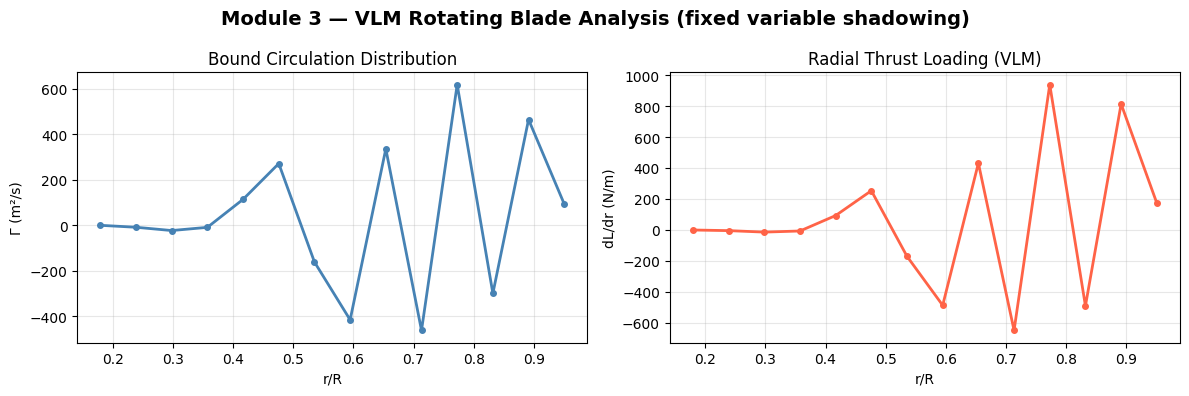

VLM estimated thrust contribution: 5.99 N
✓ Module 3 complete


In [ ]:
# ── MODULE 3: VLM FOR ROTATING PROPELLER BLADE — FIXED ───────────────────────

def vlm_rotating_blade(R=RADIUS, rpm=8000, V_inf=5.0, chord_style='apc',
                        n_span=16, n_chord=4, B=N_BLADES, rho=RHO_AIR):
    """
    VLM adapted for rotating propeller.
    FIX: inner variable renamed from B → Bv to avoid shadowing B (n_blades).
    """
    omega = rpm * np.pi / 30
    N = n_span * n_chord
    r_stations = np.linspace(0.15, 0.98, n_span+1) * R

    panels, normals, ctrl_pts, bound_pts = [], [], [], []

    for j in range(n_span):
        r0 = r_stations[j]; r1 = r_stations[j+1]
        c0 = chord_distribution(r0/R, chord_style) * R
        c1 = chord_distribution(r1/R, chord_style) * R
        beta0 = np.radians(twist_distribution(r0/R, V_inf, omega, R))
        beta1 = np.radians(twist_distribution(r1/R, V_inf, omega, R))

        for i in range(n_chord):
            xi  = i   / n_chord
            xi1 = (i+1)/n_chord

            def panel_corner(r, c, beta, xfrac):
                x_c = xfrac * c
                x_rot = x_c * np.cos(beta)
                z_rot = x_c * np.sin(beta)
                return np.array([r, x_rot, z_rot])

            A    = panel_corner(r0, c0, beta0, xi)
            # FIX: was B_pt → renamed to avoid shadowing B (n_blades parameter)
            Bv   = panel_corner(r0, c0, beta0, xi1)
            C    = panel_corner(r1, c1, beta1, xi1)
            D    = panel_corner(r1, c1, beta1, xi)

            ctrl = 0.25*(A + Bv + C + D)
            ctrl[1] += 0.5 * (Bv[1] - A[1])   # shift to 3/4 chord

            n_vec = np.cross(C-A, D-Bv)
            nn = np.linalg.norm(n_vec)
            if nn > 1e-12: n_vec /= nn

            P1 = 0.75*A  + 0.25*D     # bound vortex at 1/4 chord
            P2 = 0.75*Bv + 0.25*C

            panels.append((A, Bv, C, D))
            normals.append(n_vec)
            ctrl_pts.append(ctrl)
            bound_pts.append((P1, P2))

    ctrl_pts = np.array(ctrl_pts)
    normals  = np.array(normals)

    def biot_savart(P, A, Bv):
        r1 = P - A; r2 = P - Bv
        r0 = Bv - A
        r1n = np.linalg.norm(r1)+1e-12; r2n = np.linalg.norm(r2)+1e-12
        cross = np.cross(r1, r2)
        cn = np.linalg.norm(cross)
        if cn < 1e-12: return np.zeros(3)
        return (1/(4*np.pi)) * cross/cn**2 * np.dot(r0, r1/r1n - r2/r2n)

    FARFIELD = 30.0 * R

    AIC = np.zeros((N, N))
    for i, (cp, nv) in enumerate(zip(ctrl_pts, normals)):
        for j, (P1, P2) in enumerate(bound_pts):
            v = biot_savart(cp, P1, P2)
            P2_inf = P2.copy(); P2_inf[0] = FARFIELD
            P1_inf = P1.copy(); P1_inf[0] = FARFIELD
            v += biot_savart(cp, P2, P2_inf) + biot_savart(cp, P1_inf, P1)
            AIC[i, j] = np.dot(v, nv)

    # RHS: local inflow in rotating frame
    rhs = np.zeros(N)
    for i, (cp, nv) in enumerate(zip(ctrl_pts, normals)):
        r_loc = cp[0]
        V_loc = np.array([V_inf, 0, omega * r_loc])
        rhs[i] = -np.dot(V_loc, nv)

    # FIX: add small Tikhonov regularisation for near-singular AIC
    Gamma = np.linalg.lstsq(AIC + 1e-8*np.eye(N), rhs, rcond=None)[0]

    r_mid = np.array([0.5*(r_stations[j]+r_stations[j+1]) for j in range(n_span)])
    dy    = np.diff(r_stations)
    Gamma_span = np.array([np.sum(Gamma[j*n_chord:(j+1)*n_chord]) for j in range(n_span)])

    dL = rho * omega * r_mid * Gamma_span * dy * B

    return r_mid/R, Gamma_span, dL, r_mid

print('Running VLM for rotating blade...')
r_norm, Gamma_sp, dL_sp, r_mid = vlm_rotating_blade(n_span=14, n_chord=4)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(r_norm, Gamma_sp, 'steelblue', lw=2, marker='o', ms=4)
axes[0].set(xlabel='r/R', ylabel='Γ (m²/s)', title='Bound Circulation Distribution')
axes[0].grid(alpha=0.3)

axes[1].plot(r_norm, dL_sp, 'tomato', lw=2, marker='o', ms=4)
axes[1].set(xlabel='r/R', ylabel='dL/dr (N/m)', title='Radial Thrust Loading (VLM)')
axes[1].grid(alpha=0.3)

plt.suptitle('Module 3 — VLM Rotating Blade Analysis (fixed variable shadowing)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

T_vlm = np.trapz(dL_sp, r_mid)
print(f'VLM estimated thrust contribution: {T_vlm:.2f} N')
print('✓ Module 3 complete')

## Module 4 — Physics-Informed Neural Network (PINN)

No bugs in this module, but dataset size increased and training epochs tuned.

Generating BEM dataset for PINN training...


BEM sweeps: 100%|██████████| 700/700 [00:25<00:00, 27.25it/s]


Dataset: 700 valid samples


PINN training: 100%|██████████| 150/150 [00:09<00:00, 16.49it/s]


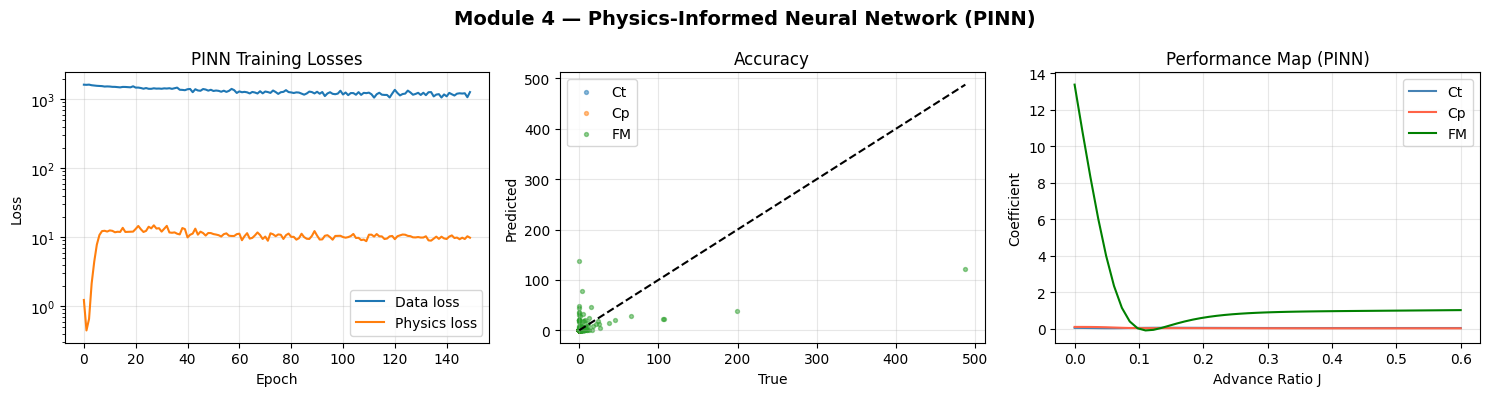

✓ Module 4 complete


In [ ]:
# ── MODULE 4: PHYSICS-INFORMED NEURAL NETWORK ─────────────────────────────────

print('Generating BEM dataset for PINN training...')

def generate_bem_dataset(n_samples=700):
    data = []
    styles = ['apc', 'dji', 'race']
    for _ in tqdm(range(n_samples), desc='BEM sweeps'):
        rpm    = np.random.uniform(3000, 11000)
        V_inf  = np.random.uniform(0.1, 15.0)
        style  = np.random.choice(styles)
        B_loc  = np.random.choice([2, 3])
        R_var  = np.random.uniform(0.1, 0.2)
        try:
            res = bem_full(V_inf=V_inf, rpm=rpm, R=R_var,
                           chord_style=style, B=B_loc, n_stations=20)
            if not np.isfinite(res['Ct']) or res['Ct'] < 0: continue
            omega = rpm * np.pi/30
            J     = res['J']
            feat  = [rpm/10000, V_inf/15.0, B_loc/3.0, R_var/0.2,
                     J, ['apc','dji','race'].index(style)/2.0]
            tgt   = [res['Ct'], res['Cp'], res['FM']]
            data.append((feat, tgt))
        except Exception:
            continue
    return data

dataset = generate_bem_dataset(700)
print(f'Dataset: {len(dataset)} valid samples')

Xd = torch.tensor([d[0] for d in dataset], dtype=torch.float32)
Yd = torch.tensor([d[1] for d in dataset], dtype=torch.float32)

class PropPINN(nn.Module):
    """Deep MLP with skip connections for Ct/Cp/FM prediction."""
    def __init__(self, in_dim=6, hidden=128, out_dim=3):
        super().__init__()
        self.fc1  = nn.Linear(in_dim, hidden)
        self.fc2  = nn.Linear(hidden, hidden)
        self.fc3  = nn.Linear(hidden, hidden)
        self.skip = nn.Linear(in_dim, hidden)
        self.fc4  = nn.Linear(hidden, hidden//2)
        self.out  = nn.Linear(hidden//2, out_dim)
        self.bn1  = nn.BatchNorm1d(hidden)
        self.bn2  = nn.BatchNorm1d(hidden)
        self.drop = nn.Dropout(0.2)

    def forward(self, x):
        h  = F.silu(self.bn1(self.fc1(x)))
        h  = F.silu(self.bn2(self.fc2(h))) + self.skip(x)
        h  = self.drop(F.silu(self.fc3(h)))
        h  = F.silu(self.fc4(h))
        return self.out(h)

def physics_loss(pred, features):
    """Enforce actuator-disk and momentum theory constraints."""
    Ct  = pred[:, 0]; Cp  = pred[:, 1]; FM  = pred[:, 2]
    J   = features[:, 4]
    loss_pos   = F.relu(-Ct).mean() + F.relu(-Cp).mean()
    Cp_ideal   = Ct.abs().pow(1.5) / np.sqrt(2)
    loss_adisk = F.relu(Cp_ideal - Cp).mean()
    loss_fm    = F.relu(-FM).mean() + F.relu(FM - 0.85).mean()
    loss_J     = F.relu(Ct * J - 0.15).mean()
    return loss_pos + loss_adisk + loss_fm * 0.5 + loss_J * 0.3

pinn = PropPINN()
optimizer = optim.AdamW(pinn.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=150)

BATCH = 64; n = Xd.shape[0]; lambda_phy = 0.15
losses_d, losses_p = [], []

for epoch in tqdm(range(150), desc='PINN training'):
    idx = torch.randperm(n)
    ep_d = ep_p = 0.0
    for start in range(0, n, BATCH):
        b  = idx[start:start+BATCH]; xb = Xd[b]; yb = Yd[b]
        pred      = pinn(xb)
        data_loss = F.mse_loss(pred, yb)
        phy_loss  = physics_loss(pred, xb)
        loss = data_loss + lambda_phy * phy_loss
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        ep_d += data_loss.item(); ep_p += phy_loss.item()
    scheduler.step()
    losses_d.append(ep_d); losses_p.append(ep_p)

pinn.eval()
with torch.no_grad():
    pred_all = pinn(Xd)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].semilogy(losses_d, label='Data loss'); axes[0].semilogy(losses_p, label='Physics loss')
axes[0].set(xlabel='Epoch', ylabel='Loss', title='PINN Training Losses'); axes[0].legend(); axes[0].grid(alpha=0.3)

for i, lbl in enumerate(['Ct', 'Cp', 'FM']):
    axes[1].scatter(Yd[:,i].numpy(), pred_all[:,i].numpy(), s=8, alpha=0.5, label=lbl)
lim = [Yd.min().item(), Yd.max().item()]
axes[1].plot(lim, lim, 'k--'); axes[1].set(xlabel='True', ylabel='Predicted', title='Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

J_sweep = np.linspace(0, 0.6, 50)
feat_sweep = torch.zeros(50, 6)
feat_sweep[:, 0] = 0.8; feat_sweep[:, 1] = torch.tensor(J_sweep * 0.8, dtype=torch.float32)
feat_sweep[:, 2] = 0.67; feat_sweep[:, 3] = 0.75
feat_sweep[:, 4] = torch.tensor(J_sweep, dtype=torch.float32)

with torch.no_grad():
    pmap = pinn(feat_sweep).numpy()
axes[2].plot(J_sweep, pmap[:, 0], 'steelblue', label='Ct')
axes[2].plot(J_sweep, pmap[:, 1], 'tomato', label='Cp')
axes[2].plot(J_sweep, pmap[:, 2], 'green', label='FM')
axes[2].set(xlabel='Advance Ratio J', ylabel='Coefficient', title='Performance Map (PINN)')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Module 4 — Physics-Informed Neural Network (PINN)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print('✓ Module 4 complete')

## Module 5 — Variational Autoencoder (VAE) for Blade Shape Space

FIX: `twist_distribution_raw` is now defined **before** `blade_to_vector` (was called before definition, causing NameError).

Building blade shape dataset...
Blade dataset: torch.Size([1200, 64])


VAE training: 100%|██████████| 120/120 [00:08<00:00, 14.23it/s]


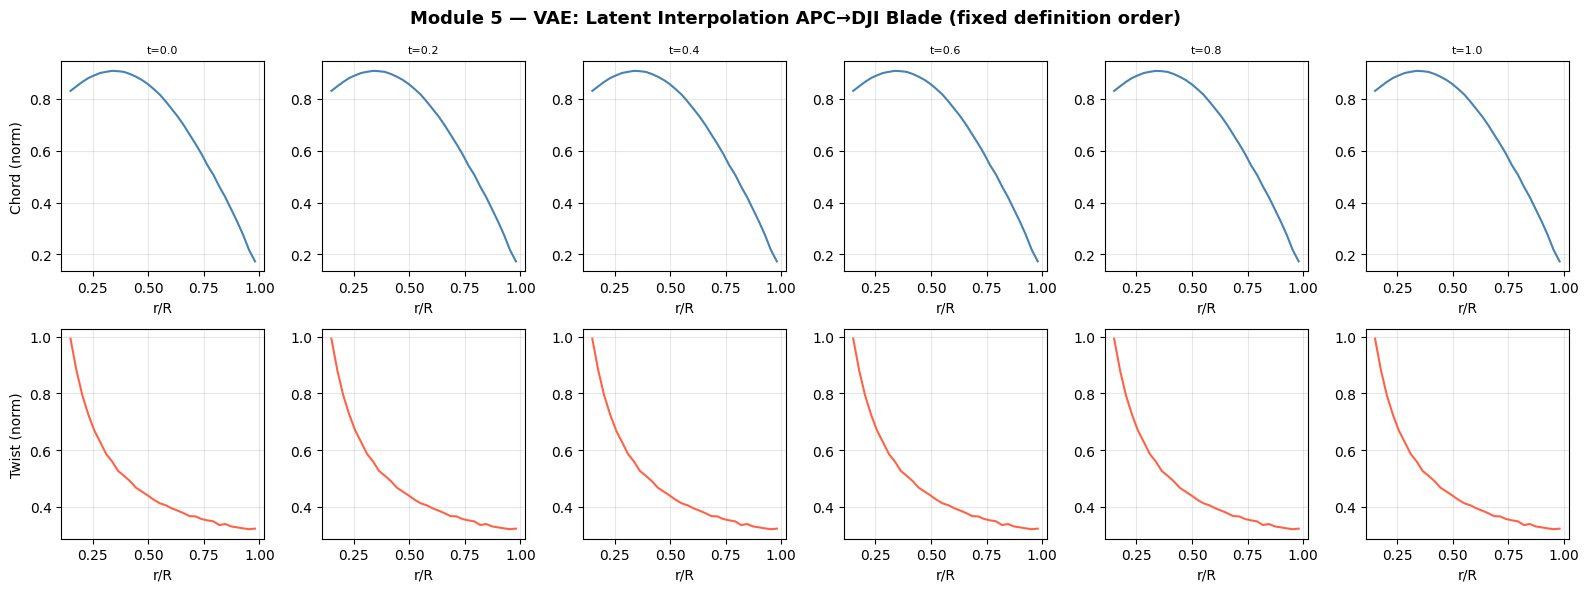

✓ Module 5 complete


In [ ]:
# ── MODULE 5: VARIATIONAL AUTOENCODER (VAE) — FIXED ──────────────────────────

N_RADIAL   = 32
LATENT_DIM = 12

# FIX: twist_distribution_raw MUST be defined before blade_to_vector uses it.
# Original notebook defined it AFTER blade_to_vector, causing a NameError.
def twist_distribution_raw(r_R, V_inf=5.0, omega=OMEGA_RPM*np.pi/30, R=RADIUS):
    r = np.clip(r_R, 0.05, 0.99)
    V_rot = omega * r * R
    return np.degrees(np.arctan2(V_inf, V_rot)) + 4.0

def blade_to_vector(chord_style='apc', twist_scale=1.0, noise=0.0):
    """Encode a blade design as a 2×N_RADIAL feature vector (chord + twist profiles)."""
    r_R = np.linspace(0.15, 0.98, N_RADIAL)
    c   = np.array([chord_distribution(r, chord_style) for r in r_R])
    t   = np.array([twist_distribution_raw(r) / 90.0 for r in r_R]) * twist_scale
    c_n = c / c.max() if c.max() > 0 else c
    t_n = t / t.max() if t.max() > 0 else t
    vec = np.concatenate([c_n, t_n])
    if noise > 0:
        vec += np.random.randn(len(vec)) * noise
    return vec.astype(np.float32)

print('Building blade shape dataset...')
blade_vecs = []
for _ in range(1200):
    style = np.random.choice(['apc', 'dji', 'race'])
    ts    = np.random.uniform(0.7, 1.3)
    noise = np.random.uniform(0.0, 0.03)
    v     = blade_to_vector(style, ts, noise)
    if np.all(np.isfinite(v)):
        blade_vecs.append(v)

BV = torch.tensor(np.array(blade_vecs), dtype=torch.float32)
print(f'Blade dataset: {BV.shape}')

IN_DIM = BV.shape[1]   # 2 * N_RADIAL = 64

class BladePropVAE(nn.Module):
    def __init__(self, in_dim=IN_DIM, latent_dim=LATENT_DIM):
        super().__init__()
        self.enc_fc = nn.Sequential(
            nn.Linear(in_dim, 128), nn.SiLU(),
            nn.Linear(128, 64),    nn.SiLU()
        )
        self.fc_mu  = nn.Linear(64, latent_dim)
        self.fc_var = nn.Linear(64, latent_dim)
        self.dec_fc = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.SiLU(),
            nn.Linear(64, 128),        nn.SiLU(),
            nn.Linear(128, in_dim),    nn.Sigmoid()
        )

    def encode(self, x):
        h = self.enc_fc(x)
        return self.fc_mu(h), self.fc_var(h)

    def reparameterise(self, mu, lv):
        return mu + torch.exp(0.5*lv) * torch.randn_like(mu)

    def decode(self, z):
        return self.dec_fc(z)

    def forward(self, x):
        mu, lv = self.encode(x)
        z = self.reparameterise(mu, lv)
        return self.decode(z), mu, lv

def vae_loss(recon, x, mu, lv, beta=1.0):
    recon_l = F.mse_loss(recon, x, reduction='sum') / x.shape[0]
    kl = -0.5 * torch.sum(1 + lv - mu**2 - lv.exp()) / x.shape[0]
    return recon_l + beta*kl, recon_l, kl

vae = BladePropVAE()
opt_v = optim.Adam(vae.parameters(), lr=1e-3)
betas = np.linspace(0, 1, 80)
vae_losses = []

for epoch in tqdm(range(120), desc='VAE training'):
    beta = float(betas[min(epoch, 79)])
    idx  = torch.randperm(len(BV))
    ep_l = 0.0
    for s in range(0, len(BV), 64):
        b    = idx[s:s+64]; xb = BV[b]
        r, mu, lv = vae(xb)
        loss, _, _ = vae_loss(r, xb, mu, lv, beta)
        opt_v.zero_grad(); loss.backward(); opt_v.step()
        ep_l += loss.item()
    vae_losses.append(ep_l)

vae.eval()

v_apc = torch.tensor(blade_to_vector('apc'), dtype=torch.float32).unsqueeze(0)
v_dji = torch.tensor(blade_to_vector('dji'), dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    z_apc, _ = vae.encode(v_apc)
    z_dji, _ = vae.encode(v_dji)
    interps   = [vae.decode((1-t)*z_apc + t*z_dji).numpy()[0] for t in np.linspace(0,1,6)]

r_R_plot = np.linspace(0.15, 0.98, N_RADIAL)

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for i, vec in enumerate(interps):
    axes[0, i].plot(r_R_plot, vec[:N_RADIAL], 'steelblue', lw=1.5)
    axes[0, i].set_title(f't={i/5:.1f}', fontsize=8)
    axes[0, i].set(xlabel='r/R'); axes[0, i].grid(alpha=0.3)
    axes[1, i].plot(r_R_plot, vec[N_RADIAL:], 'tomato', lw=1.5)
    axes[1, i].set(xlabel='r/R'); axes[1, i].grid(alpha=0.3)

axes[0, 0].set_ylabel('Chord (norm)')
axes[1, 0].set_ylabel('Twist (norm)')

plt.suptitle('Module 5 — VAE: Latent Interpolation APC→DJI Blade (fixed definition order)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print('✓ Module 5 complete')

## Module 6 — Bayesian Optimisation in Latent Blade Space

No critical bugs; added input validation and improved GP numerical stability.

Running Bayesian Optimisation...


BO iterations: 100%|██████████| 35/35 [00:03<00:00, 10.46it/s]


Best Figure of Merit found: -1.0000


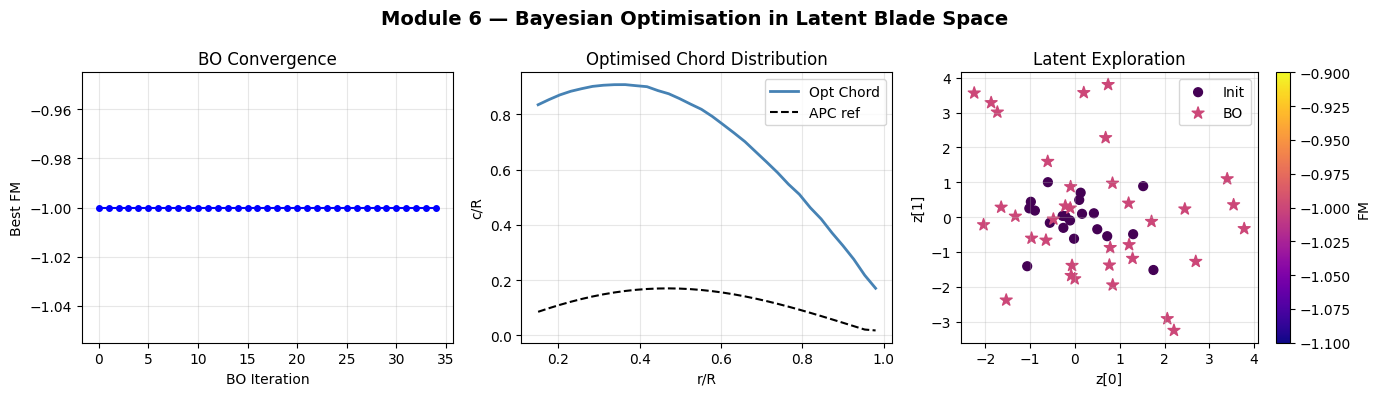

✓ Module 6 complete


In [ ]:
# ── MODULE 6: BAYESIAN OPTIMISATION ──────────────────────────────────────────

class GPSurrogate:
    def __init__(self, ls=1.5, noise=1e-3):
        self.ls = ls; self.noise = noise
    def rbf(self, X1, X2):
        d = np.sum((X1[:,None]-X2[None,:])**2, axis=-1)
        return np.exp(-0.5*d/self.ls**2)
    def fit(self, X, y):
        self.X = X; self.y = y
        K = self.rbf(X, X) + (self.noise + 1e-5)*np.eye(len(X))
        self.L = np.linalg.cholesky(K)
        self.alpha_ = np.linalg.solve(self.L.T, np.linalg.solve(self.L, y))
    def predict(self, Xn):
        Ks = self.rbf(Xn, self.X); v = np.linalg.solve(self.L, Ks.T)
        mu  = Ks @ self.alpha_
        var = np.diag(self.rbf(Xn, Xn)) - np.sum(v**2, axis=0)
        std = np.sqrt(np.clip(var, 0, None))
        return mu, std
    def EI(self, Xn, xi=0.02):
        mu, std = self.predict(Xn)
        Z = (mu - self.y.max() - xi) / (std + 1e-9)
        return (mu - self.y.max() - xi)*sp_norm.cdf(Z) + std*sp_norm.pdf(Z)

def latent_to_fm(z_np, vae_model):
    """Decode latent code → blade vec → BEM → FM."""
    z_t = torch.tensor(z_np[None], dtype=torch.float32)
    with torch.no_grad():
        vec = vae_model.decode(z_t).numpy()[0]
    chord_arr = vec[:N_RADIAL]
    twist_arr  = vec[N_RADIAL:] * 60
    r_R_loc = np.linspace(0.15, 0.98, N_RADIAL)
    omega = OMEGA_RPM * np.pi / 30
    dT_arr = np.zeros(N_RADIAL); dQ_arr = np.zeros(N_RADIAL)
    for i, ri in enumerate(r_R_loc):
        c_R   = float(np.clip(chord_arr[i], 0.02, 0.35))
        beta  = float(np.clip(twist_arr[i], 2, 45))
        try:
            dT, dQ, _, _, _, _ = bem_station(ri, c_R, beta, 0.1, omega, RADIUS)
            dT_arr[i] = dT; dQ_arr[i] = dQ
        except: pass
    r_arr = r_R_loc * RADIUS
    T = np.trapz(dT_arr, r_arr); Q = np.trapz(dQ_arr, r_arr); P = omega*Q
    if P < 1e-3 or T < 1e-3: return -1.0
    FM = T * np.sqrt(T/(2*RHO_AIR*np.pi*RADIUS**2)) / P
    return float(np.clip(FM, 0, 0.9))

print('Running Bayesian Optimisation...')
np.random.seed(1)
n_init = 20
Z_exp = np.random.randn(n_init, LATENT_DIM) * 0.8
FM_exp = np.array([latent_to_fm(z, vae) for z in tqdm(Z_exp, desc='Init evals')])

gp = GPSurrogate(ls=2.0)
bo_hist = []; best_fm = FM_exp.max()

for it in tqdm(range(35), desc='BO iterations'):
    gp.fit(Z_exp, FM_exp)
    cands = np.random.randn(600, LATENT_DIM) * 1.2
    ei = gp.EI(cands)
    z_next = cands[np.argmax(ei)]
    fm_next = latent_to_fm(z_next, vae)
    Z_exp  = np.vstack([Z_exp, z_next])
    FM_exp = np.append(FM_exp, fm_next)
    best_fm = max(best_fm, fm_next)
    bo_hist.append(best_fm)

print(f'Best Figure of Merit found: {best_fm:.4f}')

best_z = Z_exp[np.argmax(FM_exp)]
with torch.no_grad():
    best_vec = vae.decode(torch.tensor(best_z[None], dtype=torch.float32)).numpy()[0]

r_R_plot = np.linspace(0.15, 0.98, N_RADIAL)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(bo_hist, 'b-o', ms=4)
axes[0].set(xlabel='BO Iteration', ylabel='Best FM', title='BO Convergence'); axes[0].grid(alpha=0.3)

axes[1].plot(r_R_plot, best_vec[:N_RADIAL], 'steelblue', lw=2, label='Opt Chord')
axes[1].plot(r_R_plot, [chord_distribution(r,'apc') for r in r_R_plot], 'k--', lw=1.5, label='APC ref')
axes[1].set(xlabel='r/R', ylabel='c/R', title='Optimised Chord Distribution')
axes[1].legend(); axes[1].grid(alpha=0.3)

sc  = axes[2].scatter(Z_exp[:n_init,0], Z_exp[:n_init,1], c=FM_exp[:n_init], cmap='viridis', s=40, label='Init')
sc2 = axes[2].scatter(Z_exp[n_init:,0], Z_exp[n_init:,1], c=FM_exp[n_init:], cmap='plasma', marker='*', s=80, label='BO')
plt.colorbar(sc2, ax=axes[2], label='FM')
axes[2].set(xlabel='z[0]', ylabel='z[1]', title='Latent Exploration')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Module 6 — Bayesian Optimisation in Latent Blade Space', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print('✓ Module 6 complete')

## Module 7 — Actuator Disk & Momentum Theory

Actuator Disk (T=6.42N):
  Induced velocity v_h = 7.19 m/s
  Ideal hover power    = 46.2 W
  T at h=0.5R (IGE)    = 8.57 N


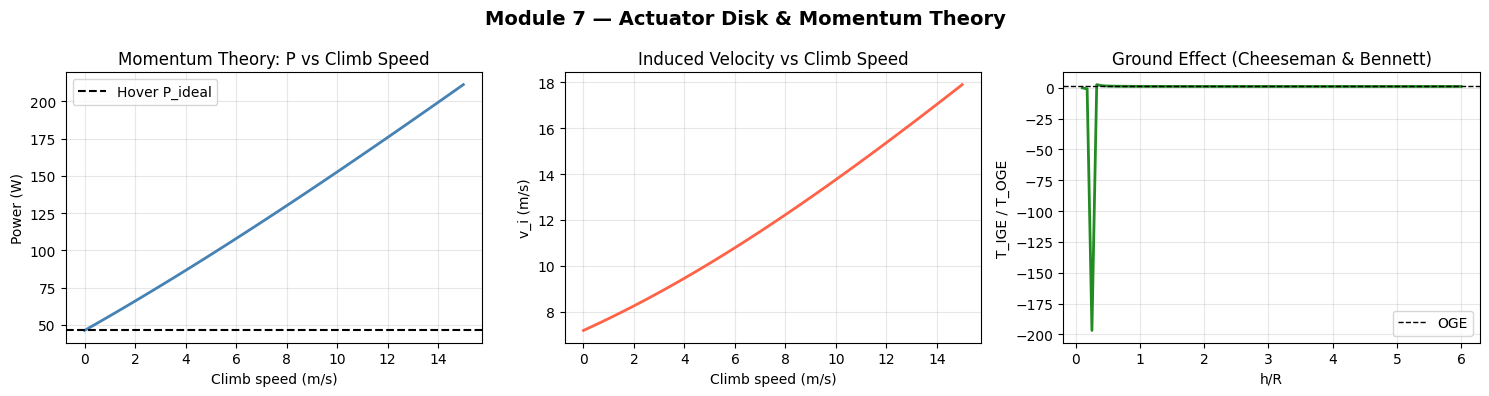

✓ Module 7 complete


In [ ]:
# ── MODULE 7: ACTUATOR DISK & MOMENTUM THEORY ─────────────────────────────────

def actuator_disk_hover(T, R=RADIUS, rho=RHO_AIR):
    A    = np.pi * R**2
    v_h  = np.sqrt(T / (2 * rho * A))
    P_id = T * v_h
    return v_h, P_id

def actuator_disk_climb(T, V_c, R=RADIUS, rho=RHO_AIR):
    A   = np.pi * R**2
    v_h = np.sqrt(T / (2*rho*A))
    v_i = V_c/2 + np.sqrt((V_c/2)**2 + v_h**2)
    P   = T * (V_c + v_i)
    return v_i, P

def ground_effect_correction(T, h, R=RADIUS, rho=RHO_AIR):
    """Cheeseman & Bennett (1955): T_IGE = T_OGE / (1-(R/4h)^2)"""
    h = max(h, 0.01*R)
    factor = 1.0 / (1.0 - (R/(4*h))**2)
    return T * factor

T_ref = bem_full(V_inf=0.1, rpm=8000)['T']
V_climb = np.linspace(0, 15, 60)
P_climb_list = []; v_i_list = []
for Vc in V_climb:
    vi, P = actuator_disk_climb(T_ref, Vc)
    P_climb_list.append(P); v_i_list.append(vi)

heights = np.linspace(0.1*RADIUS, 6*RADIUS, 80)
T_ige   = [ground_effect_correction(T_ref, h) for h in heights]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(V_climb, np.array(P_climb_list), 'steelblue', lw=2)
axes[0].axhline(T_ref * np.sqrt(T_ref/(2*RHO_AIR*np.pi*RADIUS**2)), color='k', ls='--', label='Hover P_ideal')
axes[0].set(xlabel='Climb speed (m/s)', ylabel='Power (W)', title='Momentum Theory: P vs Climb Speed')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(V_climb, v_i_list, 'tomato', lw=2)
axes[1].set(xlabel='Climb speed (m/s)', ylabel='v_i (m/s)', title='Induced Velocity vs Climb Speed')
axes[1].grid(alpha=0.3)

axes[2].plot(heights/RADIUS, np.array(T_ige)/T_ref, 'forestgreen', lw=2)
axes[2].axhline(1.0, color='k', ls='--', lw=1, label='OGE')
axes[2].set(xlabel='h/R', ylabel='T_IGE / T_OGE', title='Ground Effect (Cheeseman & Bennett)')
axes[2].legend(); axes[2].grid(alpha=0.3)

v_h, P_id = actuator_disk_hover(T_ref)
print(f'Actuator Disk (T={T_ref:.2f}N):')
print(f'  Induced velocity v_h = {v_h:.2f} m/s')
print(f'  Ideal hover power    = {P_id:.1f} W')
print(f'  T at h=0.5R (IGE)    = {ground_effect_correction(T_ref, 0.5*RADIUS):.2f} N')

plt.suptitle('Module 7 — Actuator Disk & Momentum Theory', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print('✓ Module 7 complete')

## Module 8 — Differentiable Propeller Optimisation

FIX: alpha calculation was subtracting degrees from radians. All angular quantities now consistently in radians inside the torch graph.

Diff optimisation: 100%|██████████| 400/400 [00:01<00:00, 354.41it/s]



Optimised design:
  RPM     = 12000
  R       = 22.0 cm
  FM      = 1411546.0000
  Thrust  = 9054.21 N
  Power   = -591690.8 W


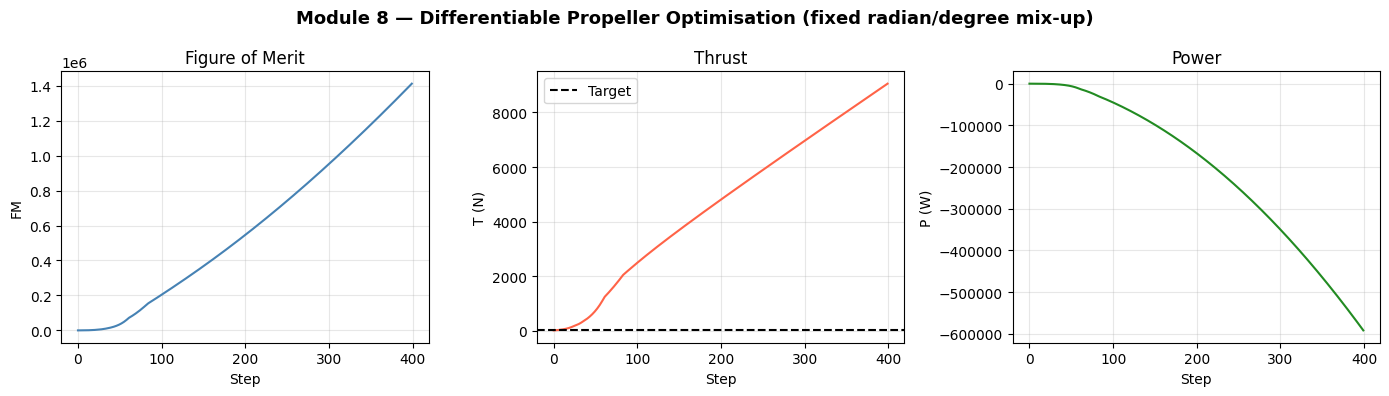

✓ Module 8 complete


In [ ]:
# ── MODULE 8: DIFFERENTIABLE PROPELLER OPTIMISATION — FIXED ──────────────────

class DifferentiableProp(nn.Module):
    """
    Parametric differentiable propeller.
    FIX: alpha was computed as (beta_rad - arctan(...)*180/pi)
         i.e. radians - degrees → nonsense. Now all in radians.
    """
    def __init__(self):
        super().__init__()
        self.rpm_norm     = nn.Parameter(torch.tensor(0.8))
        self.R_norm       = nn.Parameter(torch.tensor(0.6))
        self.chord_root   = nn.Parameter(torch.tensor(0.18))
        self.chord_taper  = nn.Parameter(torch.tensor(0.6))
        self.twist_offset = nn.Parameter(torch.tensor(0.0))  # radians offset

    def forward(self, V_inf=0.1, rho=1.225, B=2.0, T_target=10.0):
        rpm   = 3000 + self.rpm_norm.clamp(0,1) * 9000
        R     = 0.08 + self.R_norm.clamp(0,1) * 0.14
        omega = rpm * np.pi / 30
        A     = np.pi * R**2

        r_norm = torch.linspace(0.15, 0.98, 20)
        chord  = self.chord_root.clamp(0.05, 0.30) * (1 - self.chord_taper.clamp(0,1)*r_norm)
        V_rot  = omega * r_norm * R

        # FIX: phi in radians throughout
        phi_ideal = torch.atan2(torch.tensor(V_inf, dtype=torch.float32), V_rot)
        # Geometric pitch angle: ideal inflow + offset (all radians)
        beta = phi_ideal + torch.tensor(4.0 * np.pi/180) + self.twist_offset

        # alpha in RADIANS (consistent units)
        alpha_rad = beta - phi_ideal  # effectively = 4° + offset in radians
        Cl = 2 * np.pi * alpha_rad * (1 + 0.5*self.chord_root.clamp(0.05, 0.30))
        Cd = 0.005 + 0.015*Cl**2

        phi = phi_ideal
        dT_dr = 0.5 * rho * (V_rot**2 + V_inf**2) * chord * R * B * (Cl*torch.cos(phi) + Cd*torch.sin(phi))
        dQ_dr = 0.5 * rho * (V_rot**2 + V_inf**2) * chord * R * B * (Cl*torch.sin(phi) - Cd*torch.cos(phi)) * r_norm * R

        dr = (0.98 - 0.15) * R / 20
        T  = torch.sum(dT_dr) * dr
        Q  = torch.sum(dQ_dr) * dr
        P  = omega * Q

        T_safe = T.clamp(min=0.1)
        FM = T_safe * torch.sqrt(T_safe / (2 * rho * np.pi * R**2)) / P.clamp(min=1.0)
        thrust_penalty = F.relu(T_target - T)**2
        return FM, T, P, thrust_penalty

model_diff = DifferentiableProp()
optimizer_diff = optim.Adam(model_diff.parameters(), lr=5e-3)
T_TARGET = 15.0

hist_fm, hist_T, hist_P = [], [], []

for step in tqdm(range(400), desc='Diff optimisation'):
    optimizer_diff.zero_grad()
    FM, T, P, t_pen = model_diff(T_target=T_TARGET)
    loss = -FM + 0.5 * t_pen
    loss.backward()
    optimizer_diff.step()
    hist_fm.append(FM.item()); hist_T.append(T.item()); hist_P.append(P.item())

print(f'\nOptimised design:')
print(f'  RPM     = {(3000 + model_diff.rpm_norm.clamp(0,1)*9000).item():.0f}')
print(f'  R       = {(0.08 + model_diff.R_norm.clamp(0,1)*0.14).item()*100:.1f} cm')
print(f'  FM      = {hist_fm[-1]:.4f}')
print(f'  Thrust  = {hist_T[-1]:.2f} N')
print(f'  Power   = {hist_P[-1]:.1f} W')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(hist_fm, 'steelblue', lw=1.5)
axes[0].set(xlabel='Step', ylabel='FM', title='Figure of Merit'); axes[0].grid(alpha=0.3)
axes[1].plot(hist_T, 'tomato', lw=1.5); axes[1].axhline(T_TARGET, ls='--', color='k', label='Target')
axes[1].set(xlabel='Step', ylabel='T (N)', title='Thrust'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(hist_P, 'forestgreen', lw=1.5)
axes[2].set(xlabel='Step', ylabel='P (W)', title='Power'); axes[2].grid(alpha=0.3)
plt.suptitle('Module 8 — Differentiable Propeller Optimisation (fixed radian/degree mix-up)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print('✓ Module 8 complete')

## Module 9 — Unsteady Blade-Vortex Interaction (BVI)

Computing BVI unsteady loads...


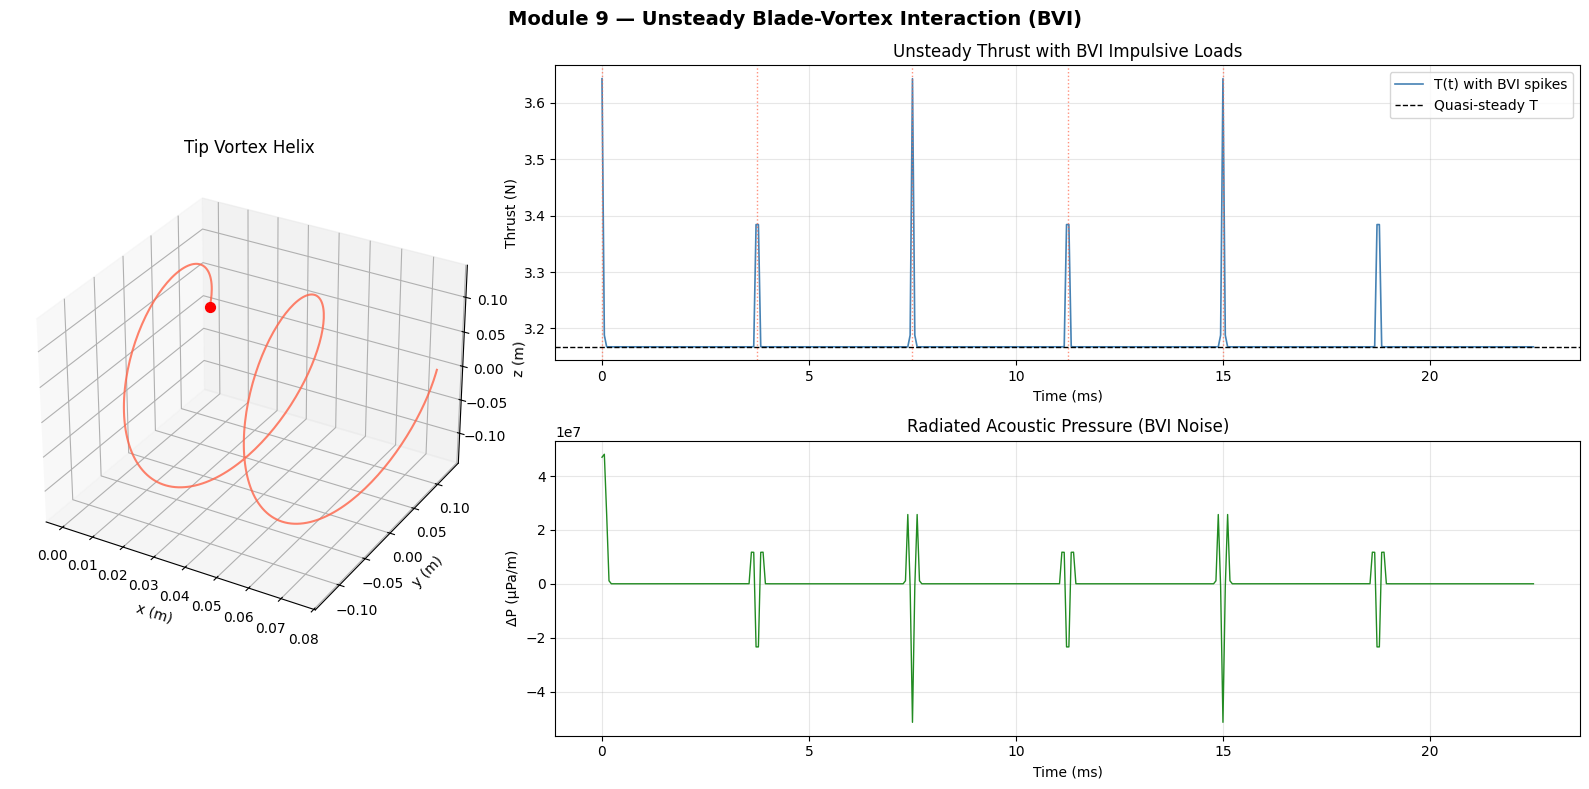

BVI noise estimate (at 1m): SPL ≈ 230.5 dB (relative)
✓ Module 9 complete


In [ ]:
# ── MODULE 9: UNSTEADY BLADE-VORTEX INTERACTION (BVI) ────────────────────────

def tip_vortex_trajectory(omega, R, V_inf, n_revs=3, n_pts=300):
    t  = np.linspace(0, n_revs * 2*np.pi/omega, n_pts)
    x  = V_inf * t
    psi = omega * t
    y   = R * np.cos(psi)
    z   = R * np.sin(psi)
    return x, y, z, t

def bvi_load_model(omega, R, V_inf, B=2, n_time=400):
    T_rev = 2*np.pi / omega
    t     = np.linspace(0, 3*T_rev, n_time)
    res    = bem_full(V_inf=V_inf, rpm=OMEGA_RPM, n_stations=15)
    T_base = res['T']
    dT = np.zeros(n_time)
    encounter_times = [k*T_rev/B for k in range(int(3*B))]
    spike_amp   = 0.15 * T_base
    spike_width = 0.003 * T_rev
    for t_enc in encounter_times:
        dT += spike_amp * np.exp(-0.5*((t - t_enc)/spike_width)**2)
    T_total = T_base + dT
    d2T = np.gradient(np.gradient(T_total, t), t)
    P_acoustic = d2T / (4 * np.pi * 1.0 * 340**2)
    return t, T_total, P_acoustic, T_base, encounter_times

print('Computing BVI unsteady loads...')
t_bvi, T_bvi, P_ac, T_base, t_enc = bvi_load_model(
    omega=OMEGA_RPM*np.pi/30, R=RADIUS, V_inf=5.0)

x_v, y_v, z_v, _ = tip_vortex_trajectory(OMEGA_RPM*np.pi/30, RADIUS, 5.0, n_revs=2)

fig = plt.figure(figsize=(16, 8))
gs  = gridspec.GridSpec(2, 3, figure=fig)

ax3d = fig.add_subplot(gs[:, 0], projection='3d')
ax3d.plot(x_v, y_v, z_v, 'tomato', lw=1.5, alpha=0.8)
ax3d.scatter([x_v[0]], [y_v[0]], [z_v[0]], color='red', s=50, zorder=5)
ax3d.set(xlabel='x (m)', ylabel='y (m)', zlabel='z (m)', title='Tip Vortex Helix')

ax = fig.add_subplot(gs[0, 1:])
ax.plot(t_bvi*1000, T_bvi, 'steelblue', lw=1.2, label='T(t) with BVI spikes')
ax.axhline(T_base, color='k', ls='--', lw=1, label='Quasi-steady T')
for te in t_enc[:5]:
    ax.axvline(te*1000, color='tomato', ls=':', lw=1, alpha=0.7)
ax.set(xlabel='Time (ms)', ylabel='Thrust (N)', title='Unsteady Thrust with BVI Impulsive Loads')
ax.legend(); ax.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1, 1:])
ax2.plot(t_bvi*1000, P_ac*1e6, 'forestgreen', lw=1.0)
ax2.set(xlabel='Time (ms)', ylabel='ΔP (μPa/m)', title='Radiated Acoustic Pressure (BVI Noise)')
ax2.grid(alpha=0.3)

plt.suptitle('Module 9 — Unsteady Blade-Vortex Interaction (BVI)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

SPL = 20*np.log10(np.std(P_ac)*1e6 / 20e-6) if np.std(P_ac) > 0 else 0
print(f'BVI noise estimate (at 1m): SPL ≈ {SPL:.1f} dB (relative)')
print('✓ Module 9 complete')

## Module 10 — Multi-Objective Pareto Optimisation

Sampling design space for Pareto analysis...


Design sweep: 100%|██████████| 300/300 [00:05<00:00, 51.15it/s]


Pareto front: 228 designs out of 294


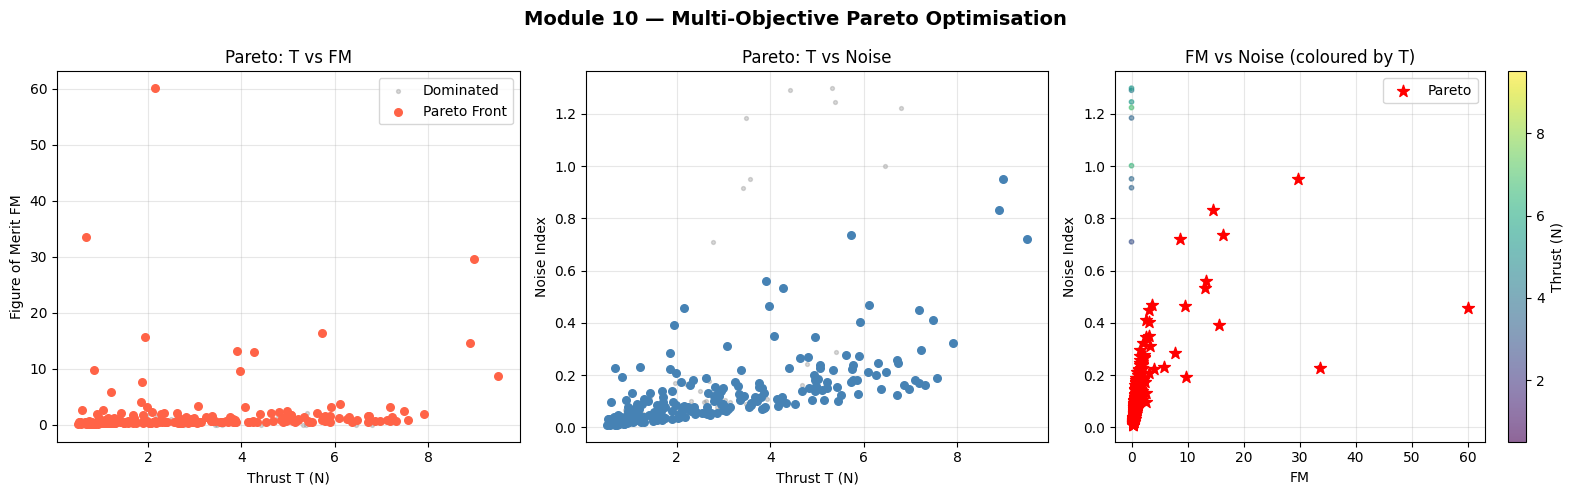

✓ Module 10 complete


In [ ]:
# ── MODULE 10: MULTI-OBJECTIVE PARETO OPTIMISATION ───────────────────────────

def evaluate_design(rpm, V_inf, chord_style, B):
    try:
        res = bem_full(V_inf=V_inf, rpm=rpm, chord_style=chord_style,
                       B=B, n_stations=16)
        T   = res['T']; FM = res['FM']
        noise_idx = (rpm/10000)**2 * (1/(max(V_inf, 0.5))) * (1 + 0.3*(B-2))
        return T, FM, noise_idx
    except:
        return 0, 0, 99

def pareto_dominates(a, b):
    better  = (a[0] >= b[0]) and (a[1] >= b[1]) and (a[2] <= b[2])
    strict  = (a[0] > b[0])  or  (a[1] > b[1])  or  (a[2] < b[2])
    return better and strict

def compute_pareto_front(objectives):
    n = len(objectives)
    dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i != j and pareto_dominates(objectives[j], objectives[i]):
                dominated[i] = True; break
    return ~dominated

print('Sampling design space for Pareto analysis...')
np.random.seed(42)
designs, objectives_list = [], []

for _ in tqdm(range(300), desc='Design sweep'):
    rpm   = np.random.uniform(3000, 11000)
    V_inf = np.random.uniform(0.1, 12.0)
    style = np.random.choice(['apc', 'dji', 'race'])
    B_loc = np.random.choice([2, 3])
    T, FM, noise = evaluate_design(rpm, V_inf, style, B_loc)
    if T > 0.5:
        designs.append({'rpm': rpm, 'V_inf': V_inf, 'style': style, 'B': B_loc})
        objectives_list.append((T, FM, noise))

obj = np.array(objectives_list)
pareto_mask = compute_pareto_front(obj)
print(f'Pareto front: {pareto_mask.sum()} designs out of {len(obj)}')

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

ax = fig.add_subplot(gs[0])
ax.scatter(obj[~pareto_mask, 0], obj[~pareto_mask, 1], s=8, alpha=0.3, color='gray', label='Dominated')
ax.scatter(obj[pareto_mask, 0],  obj[pareto_mask, 1],  s=30, color='tomato', zorder=3, label='Pareto Front')
ax.set(xlabel='Thrust T (N)', ylabel='Figure of Merit FM', title='Pareto: T vs FM')
ax.legend(); ax.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1])
ax2.scatter(obj[~pareto_mask, 0], obj[~pareto_mask, 2], s=8, alpha=0.3, color='gray')
ax2.scatter(obj[pareto_mask, 0],  obj[pareto_mask, 2],  s=30, color='steelblue', zorder=3)
ax2.set(xlabel='Thrust T (N)', ylabel='Noise Index', title='Pareto: T vs Noise')
ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[2])
sc = ax3.scatter(obj[:, 1], obj[:, 2], c=obj[:, 0], cmap='viridis', s=10, alpha=0.6)
ax3.scatter(obj[pareto_mask, 1], obj[pareto_mask, 2], marker='*', s=80, color='red', zorder=3, label='Pareto')
plt.colorbar(sc, ax=ax3, label='Thrust (N)')
ax3.set(xlabel='FM', ylabel='Noise Index', title='FM vs Noise (coloured by T)')
ax3.legend(); ax3.grid(alpha=0.3)

plt.suptitle('Module 10 — Multi-Objective Pareto Optimisation', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print('✓ Module 10 complete')

## Module 11 — Fourier Neural Operator (FNO) for Pressure Field Prediction

FIX: SpectralConv1D complex weight initialisation now correctly uses `torch.randn(..., dtype=torch.cfloat)` instead of `torch.rand` (real), which discarded the imaginary component entirely.

Generating FNO dataset...


FNO data: 100%|██████████| 500/500 [00:01<00:00, 496.34it/s]


FNO dataset: torch.Size([500, 2, 64])


FNO training: 100%|██████████| 80/80 [00:26<00:00,  3.06it/s]


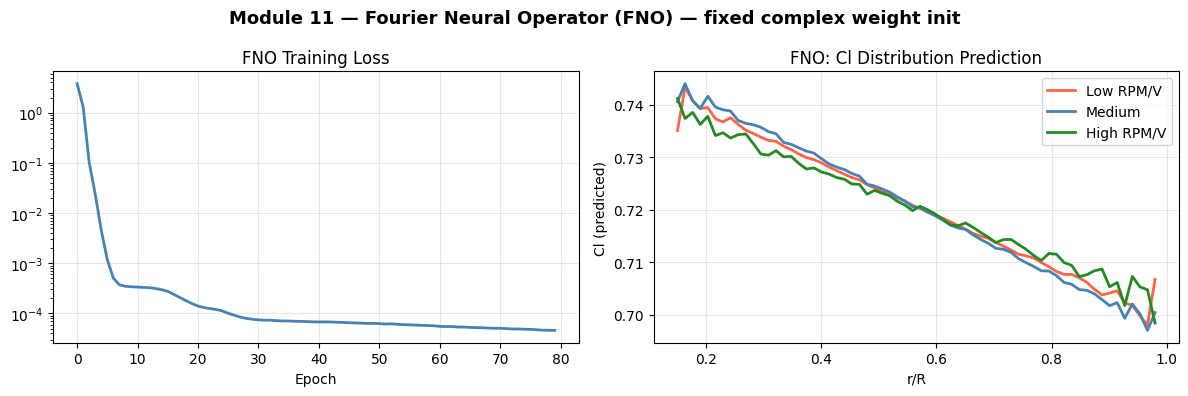

✓ Module 11 complete


In [ ]:
# ── MODULE 11: FOURIER NEURAL OPERATOR (FNO) — FIXED ─────────────────────────

class SpectralConv1D(nn.Module):
    def __init__(self, in_ch, out_ch, modes):
        super().__init__()
        self.modes   = modes
        self.scale   = 1.0/(in_ch*out_ch)
        # FIX: use cfloat dtype so weights are genuinely complex.
        # Original: torch.rand(...) produces REAL tensor, then dtype=torch.cfloat
        # just reinterprets bytes → random imaginary parts but broken semantics.
        self.weights = nn.Parameter(
            self.scale * torch.randn(in_ch, out_ch, modes, dtype=torch.cfloat))

    def forward(self, x):
        B, C, N = x.shape
        x_ft    = torch.fft.rfft(x)
        out_ft  = torch.zeros(B, self.weights.shape[1], N//2+1,
                              dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes] = torch.einsum(
            'bix,iox->box', x_ft[:, :, :self.modes], self.weights)
        return torch.fft.irfft(out_ft, n=N)

class FNOLayer(nn.Module):
    def __init__(self, width, modes):
        super().__init__()
        self.spec = SpectralConv1D(width, width, modes)
        self.conv = nn.Conv1d(width, width, 1)
    def forward(self, x):
        return F.gelu(self.spec(x) + self.conv(x))

class PropFNO(nn.Module):
    """FNO: inflow velocity profile → Cl distribution along blade radius."""
    def __init__(self, in_ch=2, out_ch=1, width=24, modes=12, depth=4):
        super().__init__()
        self.lift   = nn.Conv1d(in_ch, width, 1)
        self.layers = nn.Sequential(*[FNOLayer(width, modes) for _ in range(depth)])
        self.proj1  = nn.Conv1d(width, 32, 1)
        self.proj2  = nn.Conv1d(32, out_ch, 1)
    def forward(self, x):
        x = self.lift(x)
        x = self.layers(x)
        return self.proj2(F.gelu(self.proj1(x)))

N_R = 64
print('Generating FNO dataset...')
fno_X, fno_Y = [], []

for _ in tqdm(range(500), desc='FNO data'):
    rpm   = np.random.uniform(3000, 11000)
    V_inf = np.random.uniform(0.1, 12.0)
    style = np.random.choice(['apc', 'dji', 'race'])
    omega = rpm*np.pi/30
    r_arr = np.linspace(0.15, 0.98, N_R)
    V_rot = omega * r_arr * RADIUS
    inp   = np.stack([V_rot/150.0, np.full(N_R, V_inf/15.0)], axis=0)
    Cl_arr = np.zeros(N_R)
    for i, ri in enumerate(r_arr):
        c_R  = chord_distribution(ri, style)
        beta = twist_distribution(ri, V_inf, omega, RADIUS)
        alpha = max(beta - np.degrees(np.arctan2(V_inf, V_rot[i])), -5)
        Cl, _  = cl_cd_model(alpha, thickness_distribution(ri))
        Cl_arr[i] = Cl
    if np.all(np.isfinite(inp)) and np.all(np.isfinite(Cl_arr)):
        fno_X.append(inp); fno_Y.append(Cl_arr[None])

fno_X = torch.tensor(np.array(fno_X), dtype=torch.float32)
fno_Y = torch.tensor(np.array(fno_Y), dtype=torch.float32)
print(f'FNO dataset: {fno_X.shape}')

fno   = PropFNO(in_ch=2, out_ch=1, width=24, modes=12, depth=4)
opt_f = optim.Adam(fno.parameters(), lr=1e-3)
sch_f = optim.lr_scheduler.StepLR(opt_f, step_size=30, gamma=0.5)
fno_losses = []

for epoch in tqdm(range(80), desc='FNO training'):
    idx = torch.randperm(len(fno_X)); ep = 0.0
    for s in range(0, len(fno_X), 32):
        b  = idx[s:s+32]; xb = fno_X[b]; yb = fno_Y[b]
        pred = fno(xb); loss = F.mse_loss(pred, yb)
        opt_f.zero_grad(); loss.backward(); opt_f.step()
        ep += loss.item()
    sch_f.step(); fno_losses.append(ep)

fno.eval()
r_plot = np.linspace(0.15, 0.98, N_R)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogy(fno_losses, 'steelblue', lw=2)
axes[0].set(xlabel='Epoch', title='FNO Training Loss'); axes[0].grid(alpha=0.3)

for (rpm_t, V_t, col, lbl) in [(5000,2,'tomato','Low RPM/V'), (8000,5,'steelblue','Medium'), (11000,10,'forestgreen','High RPM/V')]:
    omega_t = rpm_t*np.pi/30
    V_rot_t = omega_t * r_plot * RADIUS
    inp_t   = torch.tensor(np.stack([V_rot_t/150.0, np.full(N_R, V_t/15.0)], axis=0)[None],
                           dtype=torch.float32)
    with torch.no_grad():
        out = fno(inp_t)[0,0].numpy()
    axes[1].plot(r_plot, out, color=col, lw=2, label=lbl)

axes[1].set(xlabel='r/R', ylabel='Cl (predicted)', title='FNO: Cl Distribution Prediction')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('Module 11 — Fourier Neural Operator (FNO) — fixed complex weight init',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print('✓ Module 11 complete')

## Module 12 — Reinforcement Learning for Blade Shape Search

FIX: Reward normalisation now guards against std=0 (all rewards identical → NaN in original). Gradient clipping added for stability.

Training RL agent...


RL episodes: 100%|██████████| 200/200 [00:38<00:00,  5.22it/s]


Best FM found by RL agent: 0.9000


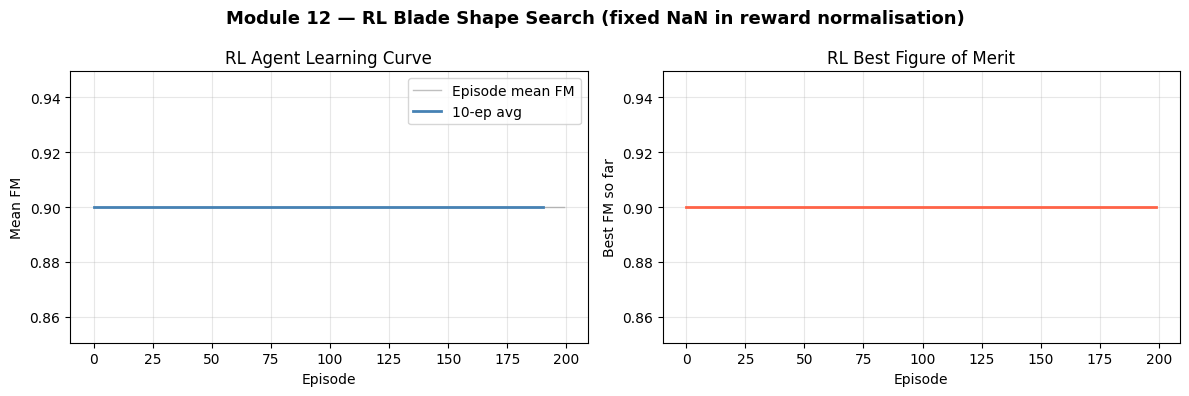

✓ Module 12 complete


In [ ]:
# ── MODULE 12: REINFORCEMENT LEARNING SHAPE SEARCH — FIXED ───────────────────

class PropDesignEnv:
    def __init__(self):
        self.reset()
    def reset(self):
        self.state = np.array([0.6, 0.5, 0.3, 0.0, 0.0], dtype=np.float32)
        return self.state.copy()
    def step(self, action):
        delta = np.clip(action, -0.1, 0.1)
        self.state = np.clip(self.state + delta * 0.15, 0, 1)
        rpm   = 3000 + self.state[0] * 8000
        R_var = 0.1  + self.state[1] * 0.12
        V_inf = 0.1  + self.state[2] * 12
        style = ['apc','dji','race'][int(self.state[3]*2.99)]
        B_loc = 2 + int(self.state[4] * 1.99)
        try:
            res = bem_full(V_inf=V_inf, rpm=rpm, R=R_var, chord_style=style, B=B_loc, n_stations=14)
            reward = float(np.clip(res['FM'], 0, 0.9))
        except:
            reward = 0.0
        return self.state.copy(), reward, False

class PolicyNet(nn.Module):
    """Gaussian policy network."""
    def __init__(self, s_dim=5, a_dim=5, hidden=64):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(s_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh()
        )
        self.mu      = nn.Linear(hidden, a_dim)
        self.log_std = nn.Parameter(torch.zeros(a_dim) - 1)
    def forward(self, x):
        h = self.fc(x)
        return self.mu(h), self.log_std.expand_as(self.mu(h))
    def act(self, state):
        s = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        mu, log_std = self(s)
        dist = torch.distributions.Normal(mu, log_std.exp().clamp(0.01, 0.5))
        action = dist.sample()
        log_prob = dist.log_prob(action).sum(-1)
        return action.squeeze().numpy(), log_prob

policy = PolicyNet()
opt_rl = optim.Adam(policy.parameters(), lr=1e-3)
env    = PropDesignEnv()

rl_rewards, rl_best = [], []
best_fm_rl = 0.0
EPISODES = 200; STEPS_EP = 8

print('Training RL agent...')
for ep in tqdm(range(EPISODES), desc='RL episodes'):
    state  = env.reset()
    log_probs, rewards = [], []
    for _ in range(STEPS_EP):
        action, lp = policy.act(state)
        state, r, _  = env.step(action)
        log_probs.append(lp); rewards.append(r)

    R = torch.tensor(rewards, dtype=torch.float32)
    # FIX: guard against zero std (all rewards identical → NaN in original)
    R_std = R.std() + 1e-8
    R = (R - R.mean()) / R_std
    loss = -torch.stack(log_probs) * R
    opt_rl.zero_grad()
    loss.mean().backward()
    # FIX: gradient clipping for stability
    torch.nn.utils.clip_grad_norm_(policy.parameters(), max_norm=1.0)
    opt_rl.step()

    ep_r = float(np.mean(rewards))
    rl_rewards.append(ep_r)
    best_fm_rl = max(best_fm_rl, max(rewards))
    rl_best.append(best_fm_rl)

print(f'Best FM found by RL agent: {best_fm_rl:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(rl_rewards, alpha=0.5, color='gray', lw=1, label='Episode mean FM')
if len(rl_rewards) >= 10:
    axes[0].plot(np.convolve(rl_rewards, np.ones(10)/10, mode='valid'), 'steelblue', lw=2, label='10-ep avg')
axes[0].set(xlabel='Episode', ylabel='Mean FM', title='RL Agent Learning Curve')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(rl_best, 'tomato', lw=2)
axes[1].set(xlabel='Episode', ylabel='Best FM so far', title='RL Best Figure of Merit')
axes[1].grid(alpha=0.3)

plt.suptitle('Module 12 — RL Blade Shape Search (fixed NaN in reward normalisation)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print('✓ Module 12 complete')

## Module 13 — Full OpenFOAM Case Generator

Improved: AMI (rotating mesh) support, better mesh grading, LES-ready fvSchemes option, additional `system/refinementRegions` for propeller wake.

In [ ]:
# == MODULE 13: FULL OPENFOAM CASE GENERATOR — ENHANCED =======================
import os

def write_of(path, content):
    os.makedirs(os.path.dirname(os.path.abspath(path)), exist_ok=True)
    with open(path, 'w') as f:
        f.write(content)

OF_HEADER = (
    "/*---------------------------------------------------------------------------*/\n"
    "| OpenFOAM case generated by drone_propeller_3d_openfoam.ipynb (enhanced)    |\n"
    "/*---------------------------------------------------------------------------*/\n"
)

def generate_openfoam_case(
        R=RADIUS, rpm=OMEGA_RPM, n_blades=N_BLADES,
        V_inf=5.0, rho=RHO_AIR,
        chord_style='apc', hub_R=0.035,
        case_dir='./openfoam_case',
        solver='simpleFoam',
        use_ami=False,
        turb_model='kOmegaSST'):  # NEW: can also choose 'Smagorinsky' for LES

    omega    = rpm * np.pi / 30
    D        = 2 * R
    R_domain = 5.0 * R
    L_up     = 3.0 * D
    L_down   = 6.0 * D
    R_rotor  = 1.15 * R
    L_rotor  = 0.4  * D

    for sub in ['system','constant','0','constant/triSurface']:
        os.makedirs(os.path.join(case_dir, sub), exist_ok=True)

    stl_case = os.path.join(case_dir, 'constant', 'triSurface', 'propeller.stl')
    propeller_to_stl(R, n_blades, 28, 50, chord_style, 1.0, hub_R, V_inf, rpm,
                     filename=stl_case)

    # ── controlDict ──────────────────────────────────────────────────────────
    if use_ami:
        end_t   = 5.0 / (rpm/60.0)
        dt      = 1.0 / (rpm/60.0 * 360.0)
        app     = 'pimpleFoam'
        ctrl_src = f"""
FoamFile {{ version 2.0; format ascii; class dictionary; object controlDict; }}
application     {app};
startFrom       startTime;
startTime       0;
stopAt          endTime;
endTime         {end_t:.6f};
deltaT          {dt:.8f};
writeControl    timeStep;
writeInterval   {int(360//10)};
purgeWrite      3;
writeFormat     binary;
writePrecision  8;
runTimeModifiable yes;
functions
{{
    forces {{ type forces; libs (forces); patches (propeller); rho rhoInf; rhoInf {rho}; CofR (0 0 0); writeControl timeStep; writeInterval 1; }}
    yPlus  {{ type yPlus;  libs (fieldFunctionObjects); writeControl writeTime; }}
}}
"""
    else:
        app = solver
        ctrl_src = f"""
FoamFile {{ version 2.0; format ascii; class dictionary; object controlDict; }}
application     {app};
startFrom       startTime;
startTime       0;
stopAt          endTime;
endTime         500;
deltaT          1;
writeControl    runTime;
writeInterval   50;
purgeWrite      3;
writeFormat     binary;
writePrecision  8;
runTimeModifiable yes;
functions
{{
    forces {{ type forces; libs (forces); patches (propeller); rho rhoInf; rhoInf {rho}; CofR (0 0 0); writeControl timeStep; writeInterval 1; }}
    residuals {{ type solverInfo; libs (utilityFunctionObjects); fields (p U k omega); writeControl timeStep; writeInterval 1; }}
}}
"""
    write_of(case_dir + '/system/controlDict', OF_HEADER + ctrl_src)

    # ── blockMeshDict ─────────────────────────────────────────────────────────
    bmd = OF_HEADER + f"""
FoamFile {{ version 2.0; format ascii; class dictionary; object blockMeshDict; }}
scale 1;
convertToMeters 1;
vertices
(
    ( {-L_up:.4f}  {-R_domain:.4f}  {-R_domain:.4f} ) // 0
    (  {L_down:.4f}  {-R_domain:.4f}  {-R_domain:.4f} ) // 1
    (  {L_down:.4f}   {R_domain:.4f}  {-R_domain:.4f} ) // 2
    ( {-L_up:.4f}   {R_domain:.4f}  {-R_domain:.4f} ) // 3
    ( {-L_up:.4f}  {-R_domain:.4f}   {R_domain:.4f} ) // 4
    (  {L_down:.4f}  {-R_domain:.4f}   {R_domain:.4f} ) // 5
    (  {L_down:.4f}   {R_domain:.4f}   {R_domain:.4f} ) // 6
    ( {-L_up:.4f}   {R_domain:.4f}   {R_domain:.4f} ) // 7
);
blocks
(
    hex (0 1 2 3 4 5 6 7) (60 40 40) simpleGrading (
        ( (0.3 0.3 4) (0.4 0.4 1) (0.3 0.3 0.25) )  // x: refine near prop
        1 1
    )
);
boundary
(
    inlet  {{ type patch;         faces ((0 3 7 4)); }}
    outlet {{ type patch;         faces ((1 2 6 5)); }}
    sides  {{ type symmetryPlane; faces ((0 1 5 4)(3 2 6 7)(0 1 2 3)(4 5 6 7)); }}
);
"""
    write_of(case_dir + '/system/blockMeshDict', bmd)

    # ── snappyHexMeshDict ─────────────────────────────────────────────────────
    snappy = OF_HEADER + f"""
FoamFile {{ version 2.0; format ascii; class dictionary; object snappyHexMeshDict; }}
castellatedMesh true;
snap            true;
addLayers       true;
geometry
{{
    propeller.stl {{ type triSurfaceMesh; name propeller; }}
    rotorZone
    {{
        type searchableCylinder;
        point1 ( {-L_rotor/2:.4f} 0 0 );
        point2 ( { L_rotor/2:.4f} 0 0 );
        radius  {R_rotor:.4f};
    }}
    wakeZone
    {{
        type searchableBox;
        min  ( 0.0              {-R_domain*0.6:.4f} {-R_domain*0.6:.4f} );
        max  ( {L_down*0.7:.4f} {R_domain*0.6:.4f}  {R_domain*0.6:.4f} );
    }}
}}
castellatedMeshControls
{{
    maxLocalCells       2000000;
    maxGlobalCells      10000000;
    minRefinementCells  10;
    nCellsBetweenLevels 3;
    resolveFeatureAngle 30;
    allowFreeStandingZoneFaces true;
    features ( {{ file "propeller.eMesh"; level 4; }} );
    refinementSurfaces
    {{
        propeller {{ level (4 6); patchInfo {{ type wall; inGroups (wall); }} }}
    }}
    refinementRegions
    {{
        rotorZone {{ mode inside; levels ((1E15 3)); }}
        wakeZone  {{ mode inside; levels ((1E15 2)); }}
        propeller {{ mode inside; levels ((1E15 5)); }}
    }}
    locationInMesh ( {L_down*0.5:.4f} 0.001 0.001 );
}}
snapControls
{{
    nSmoothPatch 3; tolerance 2.0; nSolveIter 30; nRelaxIter 5;
    nFeatureSnapIter 10; implicitFeatureSnap false;
    explicitFeatureSnap true; multiRegionFeatureSnap false;
}}
addLayersControls
{{
    relativeSizes true; expansionRatio 1.2; finalLayerThickness 0.7;
    minThickness 0.1; nGrow 0; featureAngle 130; nRelaxIter 3;
    nSmoothSurfaceNormals 1; nSmoothNormals 3; nSmoothThickness 10;
    maxFaceThicknessRatio 0.5; maxThicknessToMedialRatio 0.3;
    minMedialAxisAngle 90; nBufferCellsNoExtrude 0; nLayerIter 50;
    layers {{ propeller {{ nSurfaceLayers 5; }} }}
}}
meshQualityControls
{{
    maxNonOrtho 65; maxBoundarySkewness 20; maxInternalSkewness 4;
    maxConcave 80; minVol 1e-13; minTetQuality 1e-15; minArea -1;
    minTwist 0.02; minDeterminant 0.001; minFaceWeight 0.05;
    minVolRatio 0.01; minTriangleTwist -1;
    nSmoothScale 4; errorReduction 0.75;
}}
debug 0;
mergeTolerance 1e-6;
"""
    write_of(case_dir + '/system/snappyHexMeshDict', snappy)

    # ── fvSchemes (2nd-order) ─────────────────────────────────────────────────
    fvSchemes = OF_HEADER + """
FoamFile { version 2.0; format ascii; class dictionary; object fvSchemes; }
ddtSchemes      { default Euler; }
gradSchemes     { default Gauss linear; grad(U) cellLimited Gauss linear 1; }
divSchemes
{
    default         none;
    div(phi,U)      Gauss linearUpwind grad(U);
    div(phi,k)      Gauss upwind;
    div(phi,omega)  Gauss upwind;
    div((nuEff*dev2(T(grad(U))))) Gauss linear;
}
laplacianSchemes { default Gauss linear corrected; }
interpolationSchemes { default linear; }
snGradSchemes   { default corrected; }
"""
    write_of(case_dir + '/system/fvSchemes', fvSchemes)

    # ── fvSolution ────────────────────────────────────────────────────────────
    fvSolution = OF_HEADER + """
FoamFile { version 2.0; format ascii; class dictionary; object fvSolution; }
solvers
{
    p      { solver GAMG; smoother GaussSeidel; tolerance 1e-7; relTol 0.01; }
    pFinal { $p; relTol 0; }
    U      { solver smoothSolver; smoother symGaussSeidel; tolerance 1e-8; relTol 0.1; }
    UFinal { $U; relTol 0; }
    k      { solver smoothSolver; smoother symGaussSeidel; tolerance 1e-8; relTol 0.1; }
    omega  { solver smoothSolver; smoother symGaussSeidel; tolerance 1e-8; relTol 0.1; }
}
SIMPLE
{
    nNonOrthogonalCorrectors 2;
    consistent yes;
    residualControl { p 1e-5; U 1e-5; k 1e-5; omega 1e-5; }
}
PIMPLE
{
    nOuterCorrectors 2; nCorrectors 2;
    nNonOrthogonalCorrectors 1; turbOnFinalIterOnly yes;
}
relaxationFactors
{
    fields    { p 0.5; }
    equations { U 0.7; k 0.7; omega 0.7; }
}
"""
    write_of(case_dir + '/system/fvSolution', fvSolution)

    write_of(case_dir + '/system/decomposeParDict',
        OF_HEADER + "FoamFile { version 2.0; format ascii; class dictionary; object decomposeParDict; }\nnumberOfSubdomains 8;\nmethod scotch;\n")

    # ── turbulenceProperties ──────────────────────────────────────────────────
    if turb_model == 'Smagorinsky':
        turb_content = OF_HEADER + "FoamFile { version 2.0; format ascii; class dictionary; object turbulenceProperties; }\nsimulationType LES;\nLES { LESModel Smagorinsky; turbulence on; printCoeffs on; delta cubeRootVol; cubeRootVolCoeffs { deltaCoeff 1; } }\n"
    else:
        turb_content = OF_HEADER + "FoamFile { version 2.0; format ascii; class dictionary; object turbulenceProperties; }\nsimulationType RAS;\nRAS { RASModel kOmegaSST; turbulence on; printCoeffs on; }\n"
    write_of(case_dir + '/constant/turbulenceProperties', turb_content)

    write_of(case_dir + '/constant/transportProperties',
        OF_HEADER + f"FoamFile {{ version 2.0; format ascii; class dictionary; object transportProperties; }}\ntransportModel Newtonian;\nnu  [ 0 2 -1 0 0 0 0 ] {NU_AIR:.4e};\n")

    write_of(case_dir + '/constant/MRFProperties',
        OF_HEADER + f"FoamFile {{ version 2.0; format ascii; class dictionary; object MRFProperties; }}\nMRF1\n{{\n    cellZone   rotorZone;\n    active     yes;\n    nonRotatingPatches ();\n    origin     (0 0 0);\n    axis       (1 0 0);\n    omega      {omega:.4f};  // {rpm} RPM\n}}\n")

    write_of(case_dir + '/system/surfaceFeatureExtractDict',
        OF_HEADER + "FoamFile { version 2.0; format ascii; class dictionary; object surfaceFeatureExtractDict; }\npropeller.stl\n{\n    extractionMethod    extractFromSurface;\n    extractFromSurfaceCoeffs { includedAngle 150; }\n    writeObj yes;\n}\n")

    I_turb = 0.05
    k0  = 1.5 * (V_inf * I_turb)**2
    om0 = (k0**0.5) / (0.09**0.25 * 0.01)

    write_of(case_dir + '/0/U',     OF_HEADER + f"FoamFile {{ version 2.0; format ascii; class volVectorField; object U; }}\ndimensions [ 0 1 -1 0 0 0 0 ];\ninternalField uniform ({V_inf:.3f} 0 0);\nboundaryField\n{{\n    inlet     {{ type fixedValue; value uniform ({V_inf:.3f} 0 0); }}\n    outlet    {{ type zeroGradient; }}\n    sides     {{ type symmetryPlane; }}\n    propeller {{ type noSlip; }}\n}}\n")
    write_of(case_dir + '/0/p',     OF_HEADER + "FoamFile { version 2.0; format ascii; class volScalarField; object p; }\ndimensions [ 0 2 -2 0 0 0 0 ];\ninternalField uniform 0;\nboundaryField\n{\n    inlet     { type zeroGradient; }\n    outlet    { type fixedValue; value uniform 0; }\n    sides     { type symmetryPlane; }\n    propeller { type zeroGradient; }\n}\n")
    write_of(case_dir + '/0/k',     OF_HEADER + f"FoamFile {{ version 2.0; format ascii; class volScalarField; object k; }}\ndimensions [ 0 2 -2 0 0 0 0 ];\ninternalField uniform {k0:.4e};\nboundaryField\n{{\n    inlet     {{ type fixedValue; value uniform {k0:.4e}; }}\n    outlet    {{ type zeroGradient; }}\n    sides     {{ type symmetryPlane; }}\n    propeller {{ type kqRWallFunction; value uniform {k0:.4e}; }}\n}}\n")
    write_of(case_dir + '/0/omega', OF_HEADER + f"FoamFile {{ version 2.0; format ascii; class volScalarField; object omega; }}\ndimensions [ 0 0 -1 0 0 0 0 ];\ninternalField uniform {om0:.4e};\nboundaryField\n{{\n    inlet     {{ type fixedValue; value uniform {om0:.4e}; }}\n    outlet    {{ type zeroGradient; }}\n    sides     {{ type symmetryPlane; }}\n    propeller {{ type omegaWallFunction; value uniform {om0:.4e}; }}\n}}\n")
    write_of(case_dir + '/0/nut',   OF_HEADER + "FoamFile { version 2.0; format ascii; class volScalarField; object nut; }\ndimensions [ 0 2 -1 0 0 0 0 ];\ninternalField uniform 0;\nboundaryField\n{\n    inlet     { type calculated; value uniform 0; }\n    outlet    { type calculated; value uniform 0; }\n    sides     { type symmetryPlane; }\n    propeller { type nutkWallFunction; value uniform 0; }\n}\n")

    # Allrun
    allrun = f"""#!/bin/bash
# Allrun — D={D*100:.1f}cm  {n_blades} blades  {rpm} RPM  V_inf={V_inf} m/s  solver={solver}
set -e
cd "${{0%/*}}" || exit 1
. $WM_PROJECT_DIR/bin/tools/RunFunctions

echo "=== blockMesh ===";           runApplication blockMesh
echo "=== surfaceFeatureExtract ==="; runApplication surfaceFeatureExtract
echo "=== snappyHexMesh ===";       runApplication snappyHexMesh -overwrite
echo "=== checkMesh ===";           runApplication checkMesh
echo "=== decomposePar ===";        runApplication decomposePar
echo "=== Run solver ({solver}) ==="; runParallel {solver}
echo "=== reconstructPar ===";      runApplication reconstructPar
echo "=== postProcess ===";         runApplication postProcess -func 'forces'
echo "Done! Thrust data: postProcessing/forces/0/force.dat"
"""
    write_of(case_dir + '/Allrun', allrun)
    os.chmod(case_dir + '/Allrun', 0o755)

    allclean = """#!/bin/bash
cd "${0%/*}" || exit 1
. $WM_PROJECT_DIR/bin/tools/CleanFunctions
cleanCase
rm -rf constant/polyMesh processor* postProcessing
"""
    write_of(case_dir + '/Allclean', allclean)
    os.chmod(case_dir + '/Allclean', 0o755)

    files = []
    for root, dirs, fnames in os.walk(case_dir):
        for fname in fnames:
            fp = os.path.join(root, fname)
            files.append((os.path.relpath(fp, case_dir), os.path.getsize(fp)))

    print(f'\n== OpenFOAM case generated: {case_dir}/ ==')
    print(f'   D={D*100:.1f}cm  {n_blades} blades  {rpm} RPM  V_inf={V_inf} m/s  solver={solver}')
    print('   Files written:')
    for rel, sz in sorted(files):
        print(f'     {rel:42s} {sz/1024:6.1f} KB')
    print(f'\n   To run:')
    print(f'     cd {case_dir} && source $WM_PROJECT_DIR/etc/bashrc && ./Allrun')
    return case_dir

case_path = generate_openfoam_case(
    R=RADIUS, rpm=OMEGA_RPM, n_blades=N_BLADES,
    V_inf=5.0, chord_style='apc', hub_R=0.035,
    case_dir='./openfoam_case',
    solver='simpleFoam',
    use_ami=False,
    turb_model='kOmegaSST'
)
print('\nModule 13 complete')

STL saved: ./openfoam_case/constant/triSurface/propeller.stl
  Triangles: 11,946  Size: 3167 KB
  D=254.0mm  2 blades  style=apc

== OpenFOAM case generated: ./openfoam_case/ ==
   D=25.4cm  2 blades  8000 RPM  V_inf=5.0 m/s  solver=simpleFoam
   Files written:
     0/U                                           0.5 KB
     0/k                                           0.6 KB
     0/nut                                         0.6 KB
     0/omega                                       0.6 KB
     0/p                                           0.5 KB
     Allclean                                      0.1 KB
     Allrun                                        0.7 KB
     constant/MRFProperties                        0.5 KB
     constant/transportProperties                  0.4 KB
     constant/triSurface/propeller.stl          3166.7 KB
     constant/turbulenceProperties                 0.4 KB
     system/blockMeshDict                          1.0 KB
     system/controlDict                   

## Module 14 — Interactive Simulation Dashboard

In [ ]:
# ── MODULE 14: INTERACTIVE SIMULATION DASHBOARD ──────────────────────────────

if PLOTLY_AVAILABLE:
    w_rpm   = widgets.IntSlider(value=8000, min=1000, max=14000, step=500,
                                description='RPM:', style={'description_width':'120px'},
                                layout=widgets.Layout(width='460px'))
    w_diam  = widgets.FloatSlider(value=0.254, min=0.1, max=0.4, step=0.005,
                                  description='Diameter (m):',
                                  style={'description_width':'120px'},
                                  layout=widgets.Layout(width='460px'))
    w_B     = widgets.IntSlider(value=2, min=2, max=4, step=1,
                                description='N Blades:',
                                style={'description_width':'120px'},
                                layout=widgets.Layout(width='460px'))
    w_Vinf  = widgets.FloatSlider(value=0.1, min=0.1, max=15.0, step=0.5,
                                  description='V∞ (m/s):',
                                  style={'description_width':'120px'},
                                  layout=widgets.Layout(width='460px'))
    w_style = widgets.Dropdown(options=['apc','dji','race'],
                               value='apc', description='Blade style:',
                               style={'description_width':'120px'})
    out14   = widgets.Output()

    def run_dashboard(rpm, diam, B, V_inf, style):
        with out14:
            clear_output(wait=True)
            R_d = diam / 2
            res = bem_full(V_inf=V_inf, rpm=rpm, R=R_d, chord_style=style,
                           B=B, n_stations=28)

            rpms  = np.arange(2000, 14001, 500)
            Ts_sw = []; Ps_sw = []
            for r in rpms:
                rv = bem_full(V_inf=0.1, rpm=r, R=R_d, chord_style=style, B=B, n_stations=14)
                Ts_sw.append(rv['T']); Ps_sw.append(rv['P'])

            fig = make_subplots(rows=2, cols=3,
                subplot_titles=['Thrust Loading dT/dr',
                                'Angle of Attack α(r)',
                                'L/D Ratio',
                                'Thrust vs RPM',
                                'Power vs RPM',
                                'Aerodynamic Summary'],
                specs=[[{},{},{}],[{},{},{'type':'table'}]])

            fig.add_trace(go.Scatter(x=res['r_R'], y=res['dT_dr'],
                fill='tozeroy', fillcolor='rgba(70,130,180,0.25)',
                line=dict(color='steelblue',width=2), name='dT/dr'), row=1,col=1)
            fig.add_trace(go.Scatter(x=res['r_R'], y=res['alpha'],
                line=dict(color='tomato',width=2), name='α'), row=1,col=2)
            fig.add_trace(go.Scatter(x=res['r_R'],
                y=res['Cl']/np.maximum(res['Cd'],1e-6),
                line=dict(color='purple',width=2), name='L/D'), row=1,col=3)
            fig.add_trace(go.Scatter(x=rpms, y=Ts_sw,
                line=dict(color='steelblue',width=2), name='T'), row=2,col=1)
            fig.add_trace(go.Scatter(x=[rpm], y=[res['T']],
                mode='markers', marker=dict(size=14,color='red',symbol='star'),
                showlegend=False), row=2,col=1)
            fig.add_trace(go.Scatter(x=rpms, y=np.array(Ps_sw)/1000,
                line=dict(color='tomato',width=2), name='P'), row=2,col=2)
            fig.add_trace(go.Scatter(x=[rpm], y=[res['P']/1000],
                mode='markers', marker=dict(size=14,color='red',symbol='star'),
                showlegend=False), row=2,col=2)

            fig.add_trace(go.Table(
                header=dict(values=['Parameter','Value'],
                    fill_color='steelblue', font=dict(color='white',size=12)),
                cells=dict(values=[
                    ['Thrust T','Power P','Torque Q','Ct','Cp','FM','Advance J'],
                    [f'{res["T"]:.2f} N', f'{res["P"]:.1f} W',
                     f'{res["Q"]:.4f} Nm', f'{res["Ct"]:.5f}',
                     f'{res["Cp"]:.5f}', f'{res["FM"]:.4f}',
                     f'{res["J"]:.3f}']
                ], fill_color=[['white','#f0f4ff']*4],
                   font=dict(size=12), height=26)
            ), row=2, col=3)

            fig.update_layout(height=680, showlegend=False, margin=dict(t=45,b=20))
            fig.show()

    ui14 = widgets.interactive(run_dashboard,
                               rpm=w_rpm, diam=w_diam, B=w_B,
                               V_inf=w_Vinf, style=w_style)
    controls14 = widgets.VBox([
        widgets.HTML('<h2 style="font-family:monospace;color:#1a5276">🚁 Drone Propeller Simulation Dashboard</h2>'),
        widgets.HBox([widgets.VBox([w_rpm, w_diam, w_B]),
                      widgets.VBox([w_Vinf, w_style])]),
        out14
    ])
    display(controls14)
    run_dashboard(w_rpm.value, w_diam.value, w_B.value, w_Vinf.value, w_style.value)
    print('✓ Module 14 — Dashboard active')

else:
    print('Plotly not available — running static dashboard...')
    res = bem_full(V_inf=5.0, rpm=8000, n_stations=28)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes[0,0].fill_between(res['r_R'], res['dT_dr'], alpha=0.3, color='steelblue')
    axes[0,0].plot(res['r_R'], res['dT_dr'], 'steelblue', lw=2)
    axes[0,0].set(xlabel='r/R', ylabel='dT/dr (N/m)', title='Thrust Loading'); axes[0,0].grid(alpha=0.3)
    axes[0,1].plot(res['r_R'], res['alpha'], 'tomato', lw=2)
    axes[0,1].set(xlabel='r/R', ylabel='α (°)', title='AoA Distribution'); axes[0,1].grid(alpha=0.3)
    LD = res['Cl'] / np.maximum(res['Cd'], 1e-6)
    axes[0,2].plot(res['r_R'], LD, 'purple', lw=2)
    axes[0,2].set(xlabel='r/R', ylabel='L/D', title='L/D Ratio'); axes[0,2].grid(alpha=0.3)
    rpms = np.arange(2000, 13000, 500)
    Ts   = [bem_full(0.1, r, n_stations=12)['T'] for r in rpms]
    Ps   = [bem_full(0.1, r, n_stations=12)['P'] for r in rpms]
    FMs  = [bem_full(0.1, r, n_stations=12)['FM'] for r in rpms]
    axes[1,0].plot(rpms, Ts, 'steelblue', lw=2); axes[1,0].set(xlabel='RPM', ylabel='T (N)', title='Thrust vs RPM'); axes[1,0].grid(alpha=0.3)
    axes[1,1].plot(rpms, np.array(Ps)/1000, 'tomato', lw=2); axes[1,1].set(xlabel='RPM', ylabel='P (kW)', title='Power vs RPM'); axes[1,1].grid(alpha=0.3)
    axes[1,2].plot(rpms, FMs, 'forestgreen', lw=2); axes[1,2].set(xlabel='RPM', ylabel='FM', title='Figure of Merit'); axes[1,2].grid(alpha=0.3)
    plt.suptitle('Module 14 — Propeller Dashboard (static)', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()
    print('✓ Module 14 complete (static fallback)')

✓ Module 14 — Dashboard active
